In [1]:
from pathlib import Path

import pandas as pd
import numpy as np


def resolve_meps_dir() -> Path:
    """Walk up from CWD looking for data/MEPS/(excels/)? that contains h248a.xlsx.

    Works whether the kernel CWD is the repo root, Notebooks/, or Notebooks/MEPS/.
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "MEPS" / "excels",
        cwd / "data" / "MEPS",
        cwd / "MEPS" / "excels",
        cwd / "MEPS",
        cwd,
        cwd.parent / "data" / "MEPS" / "excels",
        cwd.parent / "data" / "MEPS",
        cwd.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent / "data" / "MEPS",
        cwd.parent.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent.parent / "data" / "MEPS",
    ]
    for d in candidates:
        if d.exists() and any(d.glob("h248a.xlsx")):
            return d
    return candidates[0]


MEPS_DIR = resolve_meps_dir()
print(f"MEPS directory: {MEPS_DIR}")


MEPS directory: /home/mehak/Documents/Personal/Friana/Medical-Adherence/data/MEPS/excels


In [2]:
df_248 = pd.read_excel(MEPS_DIR / "h248a.xlsx")

In [3]:
pd.set_option('display.max_columns', None)
df_248.head()

,DUID,PID,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PANEL,PURCHRD,RXBEGMM,RXBEGYRX,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXFRMUNT,RXSTRENG,RXSTRUNT,RXDAYSUP,PHARTP1,PHARTP2,PHARTP3,PHARTP4,PHARTP5,PHARTP6,RXFLG,IMPFLAG,PCIMPFLG,DIABEQUIP,INPCFLG,TC1,TC1S1,TC1S1_1,TC1S1_2,TC1S2,TC1S2_1,TC1S3,TC1S3_1,TC2,TC2S1,TC2S1_1,TC2S1_2,TC2S2,TC3,TC3S1,TC3S1_1,RXSF23X,RXMR23X,RXMD23X,RXPV23X,RXVA23X,RXTR23X,RXOF23X,RXSL23X,RXWC23X,RXOT23X,RXXP23X,PERWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,2790002101002,2790002101002303001,2790002101002303,27,3,-1,-1,BD PEN NEEDL,-15,8290320550,100.0,MISC,EA,-15,-15,-8,4,-1,-1,-1,-1,-1,1,4,2,1,1,-15,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,13.00,0.0,0.0,41.78,0.0,0.0,0.0,0.0,0.0,0.0,54.78,11664.426815,2019,1
1,2790002,101,2790002101,2790002101006,2790002101006403001,2790002101006403,27,4,5,2023,PREDNISONE,PREDNISONE,591544210,40.0,TABS,EA,10,MG,16,4,4,-1,-1,-1,-1,1,2,1,2,1,97,98,301,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,7.20,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,7.20,11664.426815,2019,1
2,2790002,101,2790002101,2790002101007,2790002101007403001,2790002101007403,27,4,7,2023,PREDNISONE,PREDNISONE,70954006020,10.0,TABS,EA,20,MG,5,4,4,-1,-1,-1,-1,1,5,1,2,1,97,98,301,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2.39,0.0,0.0,10.93,0.0,0.0,0.0,0.0,0.0,0.0,13.32,11664.426815,2019,1
3,2790002,101,2790002101,2790002101008,2790002101008403001,2790002101008403,27,4,-15,2020,METFORMIN,METFORMIN,70010006305,60.0,TABS,EA,500,MG,30,4,4,-1,-1,-1,-1,1,2,1,2,1,358,99,214,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,6.22,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6.22,11664.426815,2019,1
4,2790002,101,2790002101,2790002101008,2790002101008403002,2790002101008403,27,4,-15,2020,METFORMIN,METFORMIN,378718505,60.0,TABS,EA,500,MG,30,4,4,-1,-1,-1,-1,1,2,1,2,1,358,99,214,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,6.22,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6.22,11664.426815,2019,1


In [4]:
clean_df = df_248[["DUPERSID","DRUGIDX","LINKIDX","RXRECIDX","RXDAYSUP","RXNAME","RXBEGYRX","RXNDC","RXXP23X","RXSF23X","TC1","TC1S1"]]


clean_df.to_excel(MEPS_DIR / "h248a_clean.xlsx")
pd.set_option('display.max_columns', None)
clean_df.head()

,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1
0,2790002101,2790002101002,2790002101002303,2790002101002303001,-8,BD PEN NEEDL,-1,8290320550,54.78,13.00,-15,-1
1,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98
2,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98
3,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99
4,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99


In [5]:
clean_df = clean_df[clean_df["RXDAYSUP"]>0]
clean_df.head()




,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1
1,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98
2,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98
3,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99
4,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99
5,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99


In [6]:
clean_df = clean_df[clean_df["RXDAYSUP"]<990]
clean_df.shape
#clean_df.head()

(139681, 12)

In [7]:
clean_df["RXBEGYRX"].describe()

count    139681.000000
mean       1644.914197
std         783.855548
min         -15.000000
25%        2003.000000
50%        2018.000000
75%        2022.000000
max        2024.000000
Name: RXBEGYRX, dtype: float64

In [8]:
new_df_invalid = clean_df[clean_df["RXBEGYRX"]<0]
new_df_invalid.shape





(25663, 12)

In [9]:
clean_df = clean_df[clean_df["RXBEGYRX"]>0]
clean_df.shape

(114018, 12)

In [10]:
unique_rxname_df = (
    clean_df[["RXNAME"]]
    .drop_duplicates()
    .sort_values("RXNAME")
    .reset_index(drop=True)
)

unique_rxname_path = MEPS_DIR / "unique_rxname.csv"
unique_rxname_df.to_csv(unique_rxname_path, index=False)

print(f"Saved {len(unique_rxname_df)} unique drug names to {unique_rxname_path}")
unique_rxname_df.head()

Saved 1158 unique drug names to /home/mehak/Documents/Personal/Friana/Medical-Adherence/data/MEPS/excels/unique_rxname.csv


,RXNAME
0,-15
1,12HOUR NASAL
2,5-AMINOSALICYLATES
3,600+D3
4,ABILIFY MAIN


In [11]:
clean_df.columns.tolist()

['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXNDC',
 'RXXP23X',
 'RXSF23X',
 'TC1',
 'TC1S1']

In [12]:
grouped_clean_df = clean_df.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP23X = ("RXXP23X", "mean"),
    RXSF23X = ("RXSF23X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "first"),
    RXRECIDX = ("RXRECIDX", "first"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    LINKIDX = ("LINKIDX", "first")

   
)

grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  
DUPERSID   DRUGIDX                                 
2790002101 2790002101006     98  2790002101006403  
           2790002101007     98  2790002101007403  
           2790002101008     99  2790002101008403  
           2790002101009    119  2790002101009503  
2790011101 2790011101001     19  2790011101001303

In [13]:
grouped_clean_df["total_days_supply"] = np.where(grouped_clean_df["RXBEGYRX"] <=2023, 365,0).astype(int)

grouped_clean_df.shape

grouped_clean_df["total_days_supply"].describe()
#grouped_clean_df.to_excel(MEPS_DIR / "h248a_grouped.xlsx")


count    35580.000000
mean       364.189573
std         17.180146
min          0.000000
25%        365.000000
50%        365.000000
75%        365.000000
max        365.000000
Name: total_days_supply, dtype: float64

In [14]:
grouped_clean_df = grouped_clean_df[grouped_clean_df["total_days_supply"]>0]


In [15]:
grouped_clean_df["meps_adherence_ratio"] = grouped_clean_df["RXDAYSUP"]/grouped_clean_df["total_days_supply"] *100
grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006     98  2790002101006403                365   
           2790002101007     98  2790002101007403                365   
           2790002101008     99  2790002101008403                365   
           2790002101009    119  2790002101009503                365   
2790011101 2790011101001     19  2790011101001303                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101006              4.383562  
           2790002101007              1.369863  
           2790002101008             41.095890  
           2790002101009             23.013699  
2790011101 2790011101001             73.972603

In [16]:
grouped_clean_df["RXDAYSUP"].describe()
grouped_clean_df.to_excel(MEPS_DIR / "h248a_Ratio.xlsx")
#grouped_clean_df = pd.read_excel(MEPS_DIR / "h248a_Ratio.xlsx")


In [17]:
grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006     98  2790002101006403                365   
           2790002101007     98  2790002101007403                365   
           2790002101008     99  2790002101008403                365   
           2790002101009    119  2790002101009503                365   
2790011101 2790011101001     19  2790011101001303                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101006              4.383562  
           2790002101007              1.369863  
           2790002101008             41.095890  
           2790002101009             23.013699  
2790011101 2790011101001             73.972603

In [18]:
by_drug_class = (
    grouped_clean_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
20,40,42,74.618696
28,40,51,73.972603
31,40,55,71.518355
25,40,47,70.174942
14,20,23,69.895246
63,97,103,69.685220
105,358,19,69.666603
26,40,48,68.943028
32,40,56,68.796823
64,97,288,67.558421


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
73,113,266,1.538462
12,1,240,2.669477
2,1,2,2.669640
9,1,14,3.141128
7,1,11,3.160132
8,1,13,3.248117
81,122,124,3.706194
6,1,9,3.959487
86,122,132,3.988322
93,133,148,4.088514


In [19]:
top_10_highest.to_excel(MEPS_DIR / "h248a_high.xlsx")
top_10_lowest.to_excel(MEPS_DIR / "h248a_low.xlsx")

In [20]:
chronic_df = pd.read_excel(MEPS_DIR / "is_chronic.xlsx")
chronic_df.head()

,ICD10CDX,ICD10CDX_LABEL,UNWEIGHTED,WEIGHTED_BY_perwt23f,is_chronic
0,-15,CANNOT BE COMPUTED,7557,1.237057e+08,0.0
1,A08,VIRAL AND OTHER SPECIFIED INTESTINAL INFECTIONS,99,1.921659e+06,0.0
2,A49,BACTERIAL INFECTION OF UNSPECIFIED SITE,91,1.711817e+06,0.0
3,B00,HERPESVIRAL [HERPES SIMPLEX] INFECTIONS,91,1.370652e+06,0.0
4,B02,ZOSTER [HERPES ZOSTER],76,1.294114e+06,0.0


In [21]:
connecting_df = pd.read_excel(MEPS_DIR / "h248if1.xlsx")
connecting_df.head()


,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL
0,2790002101,2790002101001,2790002101001201,27900021010012790002101001201,1,27
1,2790002101,2790002101001,2790002101001801,27900021010012790002101001801,1,27
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,27
3,2790002101,2790002101004,2790002101001201,27900021010042790002101001201,1,27
4,2790002101,2790002101005,2790002101001301,27900021010052790002101001301,1,27


In [22]:
condition_df = pd.read_excel(MEPS_DIR / "h249.xlsx")
condition_df.head()

,DUID,PID,DUPERSID,CONDN,CONDIDX,PANEL,CONDRN,AGEDIAG,CRND1,CRND2,CRND3,CRND4,CRND5,INJURY,ACCDNWRK,ICD10CDX,CCSR1X,CCSR2X,CCSR3X,CCSR4X,HHCOND,IPCOND,OPCOND,OBCOND,ERCOND,RXCOND,PERWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,1,2790002101001,27,1,55,-1,-1,1,1,1,2,-1,E11,END002,END005,-1,-1,2,2,2,1,2,1,11664.426815,2019,1
1,2790002,101,2790002101,4,2790002101004,27,3,-1,-1,-1,1,1,0,2,-1,R03,SYM012,-1,-1,-1,2,2,2,1,2,2,11664.426815,2019,1
2,2790002,101,2790002101,5,2790002101005,27,4,-1,-1,-1,0,1,0,2,-1,L30,INJ031,SKN007,-1,-1,2,2,1,1,2,1,11664.426815,2019,1
3,2790002,101,2790002101,6,2790002101006,27,4,-1,-1,-1,0,1,1,2,-1,E11,END002,END005,-1,-1,2,2,2,2,2,1,11664.426815,2019,1
4,2790002,101,2790002101,8,2790002101008,27,5,-1,-1,-1,0,0,1,2,-1,E55,END007,-1,-1,-1,2,2,2,2,2,1,11664.426815,2019,1


In [23]:
condition_df = condition_df[["DUPERSID","CONDIDX","ICD10CDX","AGEDIAG"]]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG
0,2790002101,2790002101001,E11,55
1,2790002101,2790002101004,R03,-1
2,2790002101,2790002101005,L30,-1
3,2790002101,2790002101006,E11,-1
4,2790002101,2790002101008,E55,-1


In [24]:
condition_df = pd.merge(condition_df,chronic_df, on="ICD10CDX", how="left")
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,UNWEIGHTED,WEIGHTED_BY_perwt23f,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,2009,28805030.81,1.0
1,2790002101,2790002101004,R03,-1,"ABNORMAL BLOOD-PRESSURE READING, WITHOUT DIAGN...",56,868076.60,0.0
2,2790002101,2790002101005,L30,-1,OTHER AND UNSPECIFIED DERMATITIS,210,3803279.08,1.0
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,2009,28805030.81,1.0
4,2790002101,2790002101008,E55,-1,VITAMIN D DEFICIENCY,294,4622089.29,1.0


In [25]:
condition_df = condition_df.drop(columns=["UNWEIGHTED","WEIGHTED_BY_perwt23f"])
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,1.0
1,2790002101,2790002101004,R03,-1,"ABNORMAL BLOOD-PRESSURE READING, WITHOUT DIAGN...",0.0
2,2790002101,2790002101005,L30,-1,OTHER AND UNSPECIFIED DERMATITIS,1.0
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,E55,-1,VITAMIN D DEFICIENCY,1.0


In [26]:
condition_df = condition_df[condition_df["is_chronic"]>0.0]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,1.0
2,2790002101,2790002101005,L30,-1,OTHER AND UNSPECIFIED DERMATITIS,1.0
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,E55,-1,VITAMIN D DEFICIENCY,1.0
5,2790006101,2790006101002,E78,70,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1.0


In [27]:
condition_df = pd.merge(connecting_df, condition_df, on="CONDIDX", how="left")
condition_df.head()

,DUPERSID_x,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL,DUPERSID_y,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,2790002101001201,27900021010012790002101001201,1,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
1,2790002101,2790002101001,2790002101001801,27900021010012790002101001801,1,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101004,2790002101001201,27900021010042790002101001201,1,27,NaN,NaN,NaN,NaN,NaN
4,2790002101,2790002101005,2790002101001301,27900021010052790002101001301,1,27,2.790002e+09,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0


In [28]:
########
condition_df = condition_df.drop(columns=["DUPERSID_y","PANEL"])
condition_df = condition_df.rename(columns={"DUPERSID_x":"DUPERSID"})
condition_df = condition_df[condition_df["EVENTYPE"]==8]
condition_df.head()

,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
6,2790002101,2790002101005,2790002101006403,27900021010052790002101006403,8,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
7,2790002101,2790002101005,2790002101007403,27900021010052790002101007403,8,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
8,2790002101,2790002101006,2790002101008403,27900021010062790002101008403,8,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
9,2790002101,2790002101006,2790002101008503,27900021010062790002101008503,8,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [29]:
merged_df = pd.merge(clean_df, condition_df, left_on="LINKIDX", right_on="EVNTIDX", how="left")
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98,2.790002e+09,2.790002e+12,2.790002e+15,27900021010052790002101006403,8.0,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
1,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98,2.790002e+09,2.790002e+12,2.790002e+15,27900021010052790002101007403,8.0,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [30]:
merged_df.dropna(subset = ["is_chronic"],inplace=True)
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98,2.790002e+09,2.790002e+12,2.790002e+15,27900021010052790002101006403,8.0,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
1,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98,2.790002e+09,2.790002e+12,2.790002e+15,27900021010052790002101007403,8.0,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [31]:
merged_df.drop(columns=["DUPERSID_y"],inplace=True)
merged_df.rename(columns={"DUPERSID_x":"DUPERSID"},inplace=True)
merged_df = merged_df[merged_df["RXBEGYRX"]>0]
merged_df = merged_df[merged_df["RXBEGYRX"]<=2023]
merged_df = merged_df[merged_df["RXDAYSUP"]>0]
merged_df = merged_df[merged_df["RXDAYSUP"]<990]

merged_df.head()



,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,591544210,7.20,7.20,97,98,2.790002e+12,2.790002e+15,27900021010052790002101006403,8.0,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
1,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,70954006020,13.32,2.39,97,98,2.790002e+12,2.790002e+15,27900021010052790002101007403,8.0,L30,-1.0,OTHER AND UNSPECIFIED DERMATITIS,1.0
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,70010006305,6.22,6.22,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,378718505,6.22,6.22,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,68645058259,4.00,4.00,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [32]:
merged_df.to_excel(MEPS_DIR / "patient_conditions_df.xlsx")

In [33]:
merged_df.columns.to_list()


['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXNDC',
 'RXXP23X',
 'RXSF23X',
 'TC1',
 'TC1S1',
 'CONDIDX',
 'EVNTIDX',
 'CLNKIDX',
 'EVENTYPE',
 'ICD10CDX',
 'AGEDIAG',
 'ICD10CDX_LABEL',
 'is_chronic']

In [34]:
grouped_merge_df=merged_df.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP23X = ("RXXP23X", "mean"),
    RXSF23X = ("RXSF23X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "first"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    ICD10CDX = ("ICD10CDX", "first"),
    ICD10CDX_LABEL = ("ICD10CDX_LABEL", "first")
    

)
grouped_merge_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX  TC1  TC1S1 ICD10CDX  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006    591544210      2023   97     98      L30   
           2790002101007  70954006020      2023   97     98      L30   
           2790002101008  70010006305      2020  358     99      E11   
           2790002101009  42806054701      2023  115    119      E55   
2790011101 2790011101001     93720298      2021  358     19      E78   

                                                             ICD10CDX_LABEL  
DUPERSID   DRUGIDX                                                           
2790002101 2790002101006                   OTHER AND UNSPECIFIED DERMATITIS  
           2790002101007                   OTHER AND UNSPECIFIED DERMATITIS  
           2790002101008                           TYPE 2 DIABETES MELLITUS  
           2790002101009                               VITAMIN D DEFICIENCY  
2790011101 2790011101001  DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...

In [35]:
grouped_merge_df["total_valid_days"] = np.minimum(grouped_merge_df["RXDAYSUP"], 365).astype(int)

In [36]:
grouped_merge_df["total_days_supply"] = np.where(grouped_merge_df["RXBEGYRX"] <=2023, 365,0).astype(int)

In [37]:
grouped_merge_df["total_valid_days"] = np.minimum(
    grouped_merge_df["total_valid_days"],
    grouped_merge_df["total_days_supply"],
)

grouped_merge_df["meps_adherence_ratio"] = np.where(
    grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    grouped_merge_df["total_valid_days"] / grouped_merge_df["total_days_supply"] * 100,
)
grouped_merge_df.head()


RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX  TC1  TC1S1 ICD10CDX  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006    591544210      2023   97     98      L30   
           2790002101007  70954006020      2023   97     98      L30   
           2790002101008  70010006305      2020  358     99      E11   
           2790002101009  42806054701      2023  115    119      E55   
2790011101 2790011101001     93720298      2021  358     19      E78   

                                                             ICD10CDX_LABEL  \
DUPERSID   DRUGIDX                                                            
2790002101 2790002101006                   OTHER AND UNSPECIFIED DERMATITIS   
           2790002101007                   OTHER AND UNSPECIFIED DERMATITIS   
           2790002101008                           TYPE 2 DIABETES MELLITUS   
           2790002101009                               VITAMIN D DEFICIENCY   
2790011101 2790011101001  DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...   

                          total_valid_days  total_days_supply  \
DUPERSID   DRUGIDX                                              
2790002101 2790002101006                16                365   
           2790002101007                 5                365   
           2790002101008               150                365   
           2790002101009                84                365   
2790011101 2790011101001               270                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101006              4.383562  
           2790002101007              1.369863  
           2790002101008             41.095890  
           2790002101009             23.013699  
2790011101 2790011101001             73.972603

In [38]:
grouped_merge_df["meps_adherence_ratio"].describe()

count    25615.000000
mean        48.508029
std         34.247492
min          0.273973
25%         16.438356
50%         49.315068
75%         73.972603
max        100.000000
Name: meps_adherence_ratio, dtype: float64

In [39]:
patient_adherence = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
    .groupby("DUPERSID", as_index=False)
    .agg(
        total_valid_days=("total_valid_days", "sum"),
        total_days_supply=("total_days_supply", "sum"),
        drug_count=("DRUGIDX", "count"),
    )
)
patient_adherence["meps_adherence_ratio"] = (
    patient_adherence["total_valid_days"] / patient_adherence["total_days_supply"] * 100
)

top_10_high = patient_adherence.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_adherence.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patients with highest adherence:")
display(top_10_high)

print("Top 10 patients with lowest adherence:")
display(top_10_low)

Top 10 patients with highest adherence:


,DUPERSID,total_valid_days,total_days_supply,drug_count,meps_adherence_ratio
47,2790152107,365,365,1,100.0
65,2790212101,730,730,2,100.0
71,2790234101,730,730,2,100.0
72,2790234102,365,365,1,100.0
75,2790241102,1460,1460,4,100.0
157,2790501102,365,365,1,100.0
165,2790551101,365,365,1,100.0
167,2790555101,365,365,1,100.0
205,2790702101,365,365,1,100.0
213,2790718101,1095,1095,3,100.0


Top 10 patients with lowest adherence:


,DUPERSID,total_valid_days,total_days_supply,drug_count,meps_adherence_ratio
346,2791094101,1,365,1,0.273973
614,2791862101,1,365,1,0.273973
3176,2799311106,1,365,1,0.273973
3375,2810218101,1,365,1,0.273973
3798,2811117101,1,365,1,0.273973
4713,2813399102,1,365,1,0.273973
4830,2813661102,1,365,1,0.273973
7051,2818704101,1,365,1,0.273973
124,2790426101,2,365,1,0.547945
1089,2793255102,2,365,1,0.547945


In [40]:
patient_drug_df = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
)

top_10_high = patient_drug_df.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_drug_df.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patient-drug pairs with highest adherence:")
display(top_10_high)

print("Top 10 patient-drug pairs with lowest adherence:")
display(top_10_low)

Top 10 patient-drug pairs with highest adherence:


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio
66,2790067101,2790067101003,450,3.310000,0.000,ATENOLOL,93078701,2005,40,47,I10,ESSENTIAL (PRIMARY) HYPERTENSION,365,365,100.0
67,2790067101,2790067101006,460,1.460000,0.000,LOSARTAN POT,43547036009,2005,40,56,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,365,365,100.0
117,2790119102,2790119102004,450,23.460000,11.356,TRAZODONE,50111056101,2019,242,249,G47,SLEEP DISORDERS,365,365,100.0
133,2790150101,2790150101001,450,517.030000,192.375,LUMIGAN,23320505,2020,133,147,H40,GLAUCOMA,365,365,100.0
134,2790150101,2790150101002,800,4.100000,4.100,TIMOLOL MAL,61314022710,2020,133,147,H40,GLAUCOMA,365,365,100.0
142,2790152107,2790152107002,810,5.590000,5.590,ATORVASTATIN,378395177,2015,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,365,365,100.0
144,2790161101,2790161101006,380,10.555000,0.000,LISINOPRIL,68645055354,2000,40,42,I10,ESSENTIAL (PRIMARY) HYPERTENSION,365,365,100.0
162,2790172102,2790172102016,450,9.600000,2.904,METFORMIN,68645058259,2023,358,99,E11,TYPE 2 DIABETES MELLITUS,365,365,100.0
232,2790210104,2790210104005,540,53.394000,0.000,SERTRALINE,68180035309,2012,242,249,J30,VASOMOTOR AND ALLERGIC RHINITIS,365,365,100.0
239,2790210104,2790210104014,660,12.212727,0.000,FLUTICASONE,60505082901,2018,133,247,J30,VASOMOTOR AND ALLERGIC RHINITIS,365,365,100.0


Top 10 patient-drug pairs with lowest adherence:


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio
1223,2791094101,2791094101006,1,15.00,15.00,LATANOPROST,59762033302,2023,133,147,H40,GLAUCOMA,1,365,0.273973
1794,2791537101,2791537101007,1,3.85,3.85,HYDROCO/APAP,406012305,2023,57,58,K82,OTHER DISEASES OF GALLBLADDER,1,365,0.273973
2190,2791862101,2791862101008,1,199.22,178.14,CLENPIQ,55566670001,2023,87,95,K59,OTHER FUNCTIONAL INTESTINAL DISORDERS,1,365,0.273973
3091,2792644101,2792644101015,1,0.13,0.13,LORAZEPAM,69315090405,2023,57,64,F41,OTHER ANXIETY DISORDERS,1,365,0.273973
3261,2792764101,2792764101005,1,6.00,1.33,OXYCOD/APAP,406051205,2023,57,58,N42,OTHER AND UNSPECIFIED DISORDERS OF PROSTATE,1,365,0.273973
3980,2793371101,2793371101011,1,1.32,1.32,METRONIDAZOL,72578000805,2023,1,2,G89,"PAIN, NOT ELSEWHERE CLASSIFIED",1,365,0.273973
6585,2795669102,2795669102011,1,0.51,0.51,CLINDAMYCIN,65862018601,2023,1,240,M25,"OTHER JOINT DISORDER, NOT ELSEWHERE CLASSIFIED",1,365,0.273973
7704,2796492101,2796492101016,1,4.00,0.00,LORAZEPAM,93342601,2023,57,64,N32,OTHER DISORDERS OF BLADDER,1,365,0.273973
7779,2796548101,2796548101007,1,0.50,0.50,DIAZEPAM,172392670,2023,57,64,F41,OTHER ANXIETY DISORDERS,1,365,0.273973
8783,2797355101,2797355101012,1,3.16,3.16,KETOROLAC,93031401,2023,57,58,H57,OTHER DISORDERS OF EYE AND ADNEXA,1,365,0.273973


In [41]:
adherence_threshold = 60


In [42]:
print(grouped_merge_df["ICD10CDX"].nunique())
print(grouped_merge_df["TC1"].nunique())
print(grouped_merge_df["RXNAME"].nunique())
print(grouped_merge_df["TC1S1"].nunique())

136
17
863
93


In [43]:
grouped_merge_df.to_excel(MEPS_DIR / "grouped_merge_df.xlsx")

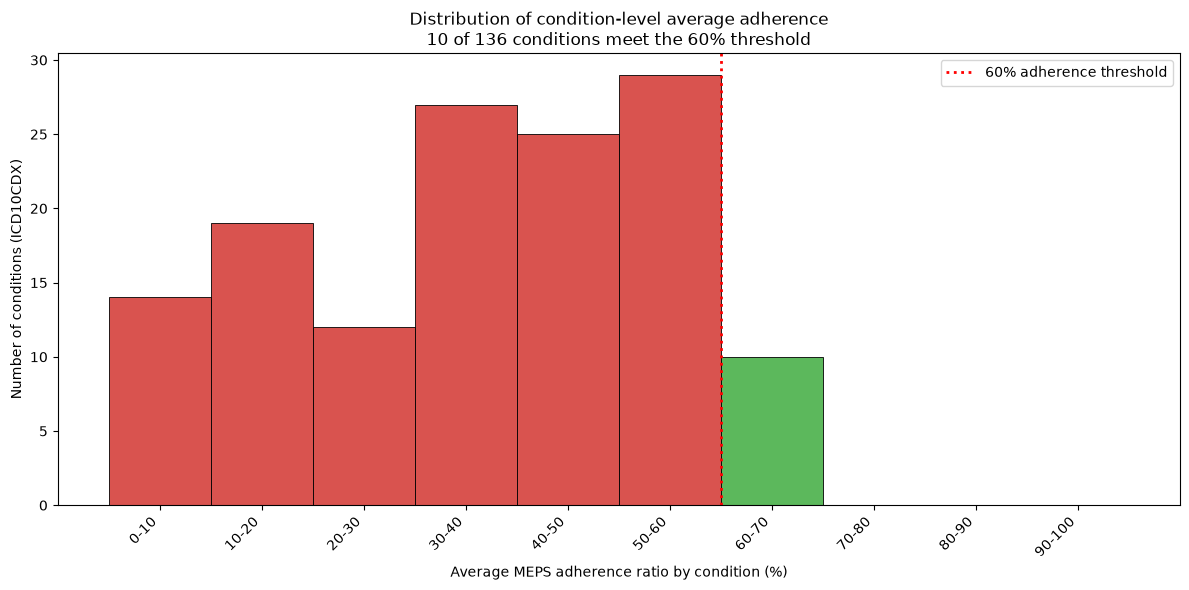

Adherent conditions (>=60%):


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
36,F84,PERVASIVE DEVELOPMENTAL DISORDERS,66.514460
30,F20,SCHIZOPHRENIA,65.664224
17,E06,THYROIDITIS,64.488415
14,E03,OTHER HYPOTHYROIDISM,63.786657
129,R54,AGE-RELATED PHYSICAL DEBILITY,62.808219
31,F31,BIPOLAR DISORDER,62.795766
58,I10,ESSENTIAL (PRIMARY) HYPERTENSION,62.344497
27,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,62.282012
60,I25,CHRONIC ISCHEMIC HEART DISEASE,61.480324
29,F19,OTHER PSYCHOACTIVE SUBSTANCE RELATED DISORDERS,60.563166


In [44]:
import matplotlib.pyplot as plt

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_condition["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_condition["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_condition)

ax.set_xlabel("Average MEPS adherence ratio by condition (%)")
ax.set_ylabel("Number of conditions (ICD10CDX)")
ax.set_title(
    f"Distribution of condition-level average adherence\n"
    f"{n_adherent} of {n_total} conditions meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_conditions = by_condition[
    by_condition["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent conditions (>={adherence_threshold}%):")
display(adherent_conditions)

Pearson correlation with meps_adherence_ratio
(ICD10CDX uses label encoding; interpret as a weak linear proxy only)



,pearson_r
ICD10CDX_code,-0.200039
TC1,0.158889
TC1S1,-0.000106



Eta-squared with meps_adherence_ratio
(better measure for categorical variables: share of variance explained)



,eta_squared
ICD10CDX,0.188451
TC1,0.149065
TC1S1,0.211886



Combined model: ICD10CDX + TC1 + TC1S1 together
  R-squared: 0.2412
  Adjusted R-squared: 0.2339


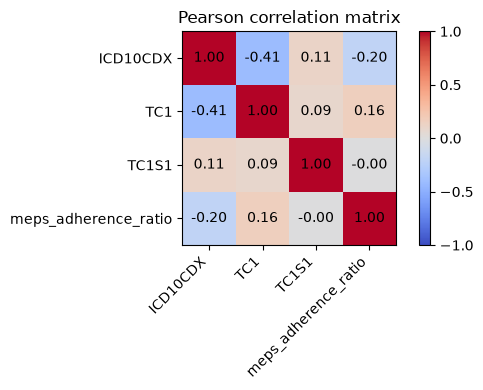

In [45]:
from sklearn.preprocessing import LabelEncoder

corr_df = grouped_merge_df.reset_index()[
    ["ICD10CDX", "TC1", "TC1S1", "meps_adherence_ratio"]
].dropna()

corr_df["ICD10CDX_code"] = LabelEncoder().fit_transform(corr_df["ICD10CDX"].astype(str))


def eta_squared(categorical, continuous):
    """Share of adherence variance explained by a categorical variable."""
    categories = categorical.astype(str)
    grand_mean = continuous.mean()
    ss_total = ((continuous - grand_mean) ** 2).sum()
    ss_between = sum(
        len(continuous[categories == cat]) * (continuous[categories == cat].mean() - grand_mean) ** 2
        for cat in categories.unique()
    )
    return ss_between / ss_total if ss_total > 0 else np.nan


pearson_corr = corr_df[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"]
].corr(method="pearson")

pearson_with_adherence = pearson_corr["meps_adherence_ratio"].drop("meps_adherence_ratio")

eta_results = pd.Series(
    {
        "ICD10CDX": eta_squared(corr_df["ICD10CDX"], corr_df["meps_adherence_ratio"]),
        "TC1": eta_squared(corr_df["TC1"], corr_df["meps_adherence_ratio"]),
        "TC1S1": eta_squared(corr_df["TC1S1"], corr_df["meps_adherence_ratio"]),
    },
    name="eta_squared",
)

X = pd.get_dummies(
    corr_df[["ICD10CDX", "TC1", "TC1S1"]].astype(str),
    drop_first=True,
).astype(float)
y = corr_df["meps_adherence_ratio"].values
X_with_intercept = np.column_stack([np.ones(len(X)), X.values])
coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
y_pred = X_with_intercept @ coeffs
ss_res = ((y - y_pred) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
combined_r2 = 1 - ss_res / ss_tot
n, p = len(y), X.shape[1]
adj_r2 = 1 - (1 - combined_r2) * (n - 1) / (n - p - 1)

print("Pearson correlation with meps_adherence_ratio")
print("(ICD10CDX uses label encoding; interpret as a weak linear proxy only)\n")
display(pearson_with_adherence.to_frame("pearson_r"))

print("\nEta-squared with meps_adherence_ratio")
print("(better measure for categorical variables: share of variance explained)\n")
display(eta_results.to_frame())

print("\nCombined model: ICD10CDX + TC1 + TC1S1 together")
print(f"  R-squared: {combined_r2:.4f}")
print(f"  Adjusted R-squared: {adj_r2:.4f}")

heatmap_data = pearson_corr.loc[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
].rename(index={"ICD10CDX_code": "ICD10CDX"}, columns={"ICD10CDX_code": "ICD10CDX"})

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heatmap_data.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f"{heatmap_data.iloc[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

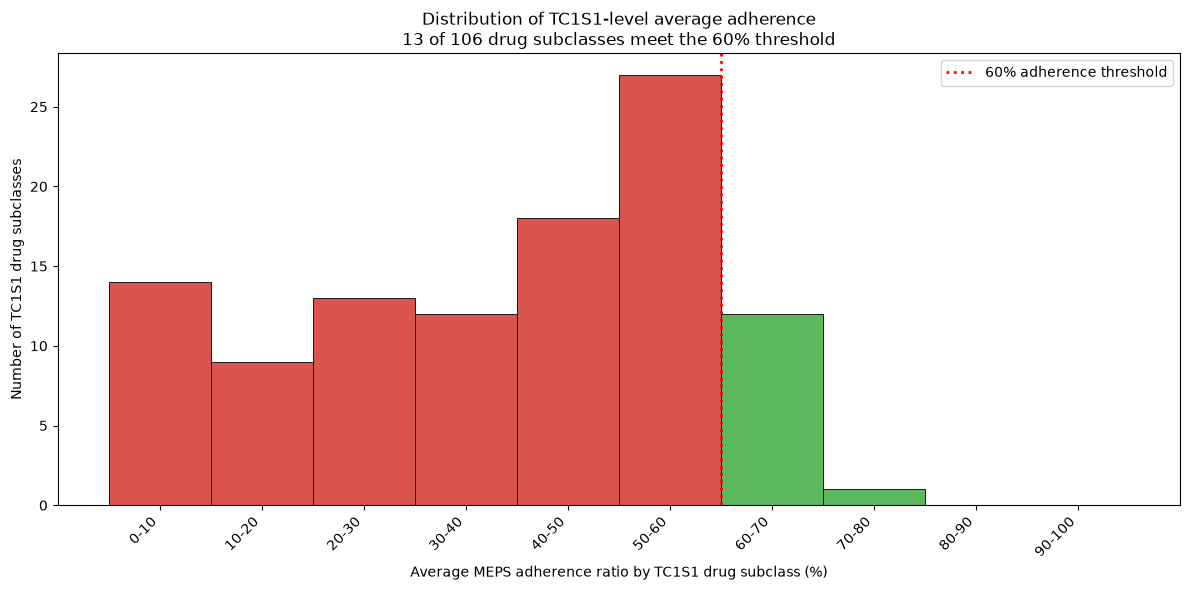

Adherent TC1S1 drug subclasses (>=60%):


,TC1,TC1S1,meps_adherence_ratio
27,40,51,74.246575
66,105,106,69.041096
99,242,504,67.042707
14,20,23,65.887225
30,40,55,65.287825
19,40,42,64.485197
24,40,47,63.552036
62,97,103,63.043864
102,358,19,62.847522
63,97,288,62.834667


In [46]:
by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_tc1s1["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_tc1s1["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_tc1s1)

ax.set_xlabel("Average MEPS adherence ratio by TC1S1 drug subclass (%)")
ax.set_ylabel("Number of TC1S1 drug subclasses")
ax.set_title(
    f"Distribution of TC1S1-level average adherence\n"
    f"{n_adherent} of {n_total} drug subclasses meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_tc1s1 = by_tc1s1[
    by_tc1s1["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent TC1S1 drug subclasses (>={adherence_threshold}%):")
display(adherent_tc1s1)

In [47]:
low_adherence_threshold = 10

by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 10%:
Count: 14 of 106


,TC1,TC1S1,meps_adherence_ratio
29,40,54,2.092154
2,1,2,2.273973
91,133,148,2.328767
72,113,266,3.209393
8,1,13,3.650881
6,1,9,3.894977
7,1,11,3.942161
9,1,14,4.074238
12,1,240,4.726027
3,1,4,5.296804



ICD10CDX conditions with average adherence < 10%:
Count: 14 of 136


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
56,H91,OTHER AND UNSPECIFIED HEARING LOSS,3.698630
98,M21,OTHER ACQUIRED DEFORMITIES OF LIMBS,3.757339
135,Z97,PRESENCE OF OTHER DEVICES,6.027397
108,M65,SYNOVITIS AND TENOSYNOVITIS,6.210046
52,H44,DISORDERS OF GLOBE,6.259678
67,J32,CHRONIC SINUSITIS,6.579584
134,Z96,PRESENCE OF OTHER FUNCTIONAL IMPLANTS,7.733623
3,C44,OTHER AND UNSPECIFIED MALIGNANT NEOPLASM OF SKIN,7.880317
2,C43,MALIGNANT MELANOMA OF SKIN,8.258317
82,K57,DIVERTICULAR DISEASE OF INTESTINE,8.853993


In [48]:
demo_df = pd.read_excel(MEPS_DIR / "h251.xlsx")
demo_df.head()

,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID23,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR23,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE23,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS23,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE23,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION23,REFPRS31,REFPRS42,REFPRS53,REFPRS23,RESP31,RESP42,RESP53,RESP23,PROXY31,PROXY42,PROXY53,PROXY23,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM23,ENDRFY23,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP23,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND23,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE23X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY23X,SPOUID31,SPOUID42,SPOUID53,SPOUID23,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN23,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU23X,ACTDTY31,ACTDTY42,ACTDTY53,EVERSERVED,REFRL31X,REFRL42X,REFRL53X,REFRL23X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER31,COVIDEVER53,LCEVER31,LCEVER53,COVSYMNOW31,COVSYMNOW53,COVREDABIL31,COVREDABIL53,COVID12MO31,COVID12MO53,COVMNTHX31,COVMNTHX53,COVYRDX31,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI23,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,GETTRB42,MOMPRO42,DADPRO42,UNHAP42,SCHLBH42,HAVFUN42,ADUPRO42,NERVAF42,SIBPRO42,KIDPRO42,SPRPRO42,SCHPRO42,HOMEBH42,CHILCR42,CHILWW42,CHRTCR42,CHRTWW42,CHAPPT42,CHLIST42,CHEXPL42,CHRESP42,CHPRTM42,CHHECR42,CHSPEC42_M18,CHEYRE42_M18,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,COVAXNEW31,COVAXNEW42,COVAXNEW53,SAQELIG,ADPROX42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADINSA42,ADINSB42,ADRISK42,ADOVER42,ADILCR42,ADILWW42,ADRTCR42,ADRTWW42,ADAPPT42,ADHECR42,ADINST42,ADEZUN42,ADTLHW42,ADFFRM42,ADFHLP42,ADEXPL42,ADLIST42,ADRESP42,ADPRTM42,ADSMOK42,ADNSMK42,ADSPCL42,ADSNSP42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,DDNWRK23,OTHDYS23,OTHNDD23,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,PROVSEX42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPST53,RNDFLG31,MORJOB31,MORJOB42,MORJOB53,EVRWRK,HRWG31X,HRWG42X,HRWG53X,HRWGIM31,HRWGIM42,HRWGIM53,HRHOW31,HRHOW42,HRHOW53,DIFFWG31,DIFFWG42,DIFFWG53,NHRWGRND31,NHRWGRND42,NHRWGRND53,NHRWG31_M23,NHRWG42_M23,NHRWG53_M23,HOUR31,HOUR42,HOUR53,TEMPJB31,TEMPJB42,TEMPJB53,SSNLJB31,SSNLJB42,SSNLJB53,SELFCM31,SELFCM42,SELFCM53,DISVW31X,DISVW42X,DISVW53X,CHOIC31,CHOIC42,CHOIC53,INDCAT31,INDCAT31_17,INDCAT42_17,INDCAT53_17,NUMEMP31,NUMEMP42,NUMEMP53,MORE31,MORE42,MORE53,UNION31,UNION42,UNION53,NWK31,NWK42,NWK53,CHGJ3142,CHGJ4253,YCHJ3142,YCHJ4253,STJBMM31,STJBYY31,STJBMM42,STJBYY42,STJBMM53,STJBYY53,EVRETIRE,OCCCAT31,OCCCAT31_18,OCCCAT42_18,OCCCAT53_18,PAYVAC31,PAYVAC42,PAYVAC53,SICPAY31,SI

In [49]:
new_demo_df = demo_df[["DUPERSID","AGE23X","SEX","INSCOV23","POVCAT23","FAMINC23","PSTATS31","PSTATS53",
"PSTATS42","RACEV2X","BEGRFM31", "BEGRFY31", "BEGRFM42", "BEGRFY42", "BEGRFM53","BEGRFY53", "ENDRFM31", "ENDRFY31",
 "ENDRFM42", "ENDRFY42", "ENDRFM53",
"ENDRFY53","DLAYPM42","DLAYCA42"]]
new_demo_df.head()

,DUPERSID,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
0,2790002101,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
1,2790002102,27,1,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
2,2790004101,49,2,1,5,87000,11,11,11,1,10,2022,5,2023,9,2023,5,2023,9,2023,12,2023,2,2
3,2790006101,75,2,2,4,38000,11,11,11,1,8,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
4,2790006102,23,1,2,4,38000,11,11,11,1,8,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2


In [50]:
##1 - Any private (Person had any private insurance coverage [including
#TRICARE/CHAMPVA] at any time during 2023)
#2 - Public only (Person had only public insurance coverage [excluding
#TRICARE/CHAMPVA] during 2023)
#3 - Uninsured (Person was uninsured during all of 2023)

In [51]:
#POVCAT23 - Poverty level

#1 is Poor
#5 is high income

#PSTATS31 - if val is 31 - deseaced 

In [52]:

new_grouped_merge_df = grouped_merge_df.merge(new_demo_df, on="DUPERSID", how="left")
new_grouped_merge_df.head()


,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
0,2790002101,16,7.200,7.200,PREDNISONE,591544210,2023,97,98,L30,OTHER AND UNSPECIFIED DERMATITIS,16,365,4.383562,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
1,2790002101,5,13.320,2.390,PREDNISONE,70954006020,2023,97,98,L30,OTHER AND UNSPECIFIED DERMATITIS,5,365,1.369863,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
2,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,365,41.095890,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
3,2790002101,84,21.090,0.000,VITAMIN D,42806054701,2023,115,119,E55,VITAMIN D DEFICIENCY,84,365,23.013699,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
4,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,73.972603,71,1,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2


In [53]:
pstat_cols = ["PSTATS31", "PSTATS53", "PSTATS42"]
missing = [c for c in pstat_cols if c not in new_grouped_merge_df.columns]
if missing:
    raise KeyError(
        f"Missing {missing}. Re-run from the new_demo_df / merge cells "
        "(PSTATS columns are dropped later after reference-days are computed)."
    )

pstat_values = [31, 23, 24, 61]

pstat_df = new_grouped_merge_df.loc[
    new_grouped_merge_df["PSTATS31"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS53"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS42"].isin(pstat_values)
]

print(pstat_df.shape)
pstat_df.head()

(251, 37)


,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,total_days_supply,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
1182,2791067101,180,8.200000,8.200000,CARVEDILOL,68382009505,2022,40,47,I48,ATRIAL FIBRILLATION AND FLUTTER,180,365,49.315068,-1,2,1,3,22800,11,-1,31,1,8,2022,2,2023,-1,-1,2,2023,3,2023,-1,-1,-1,-1
1575,2791395101,180,0.000000,0.000000,AMLODIPINE,68180072003,2018,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1576,2791395101,180,12.000000,12.000000,METOPROL SUC,55111046605,2018,40,47,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1577,2791395101,284,9160.866667,2577.953333,ANTINEOPLASTICS,-15,2017,20,-15,C50,MALIGNANT NEOPLASM OF BREAST,284,365,77.808219,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1934,2791637101,90,38.320000,5.000000,NIFEDIPINE,50742062001,2002,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,90,365,24.657534,-1,2,2,3,25770,31,-1,-1,1,8,2022,-1,-1,-1,-1,2,2023,-1,-1,-1,-1,-1,-1


In [54]:
pstat_values = [31,11, 12, 13, 14, 21, 22, 31, 32, 33, 34, 35, 41, 42, 43, 44, 51, 74, -1  ]
pstat_cols = ["PSTATS31", "PSTATS53", "PSTATS42"]
missing = [c for c in pstat_cols if c not in new_grouped_merge_df.columns]
if missing:
    raise KeyError(
        f"Missing {missing}. Re-run from the new_demo_df / merge cells "
        "(PSTATS columns are dropped later after reference-days are computed)."
    )

for val in pstat_values:
    mask = new_grouped_merge_df[pstat_cols].eq(val).any(axis=1)
    subset = new_grouped_merge_df.loc[mask, "total_valid_days"]
    print(f"PSTATS value {val} (rows where any PSTATS column == {val}): {len(subset)}")
    if len(subset) == 0:
        print("  No rows found.\n")
    else:
        display(subset.describe().to_frame(f"total_valid_days (PSTATS={val})"))
        print()

PSTATS value 31 (rows where any PSTATS column == 31): 251


,total_valid_days (PSTATS=31)
count,251.000000
mean,141.175299
std,104.742127
min,1.000000
25%,58.000000
50%,118.000000
75%,187.000000
max,365.000000



PSTATS value 11 (rows where any PSTATS column == 11): 25549


,total_valid_days (PSTATS=11)
count,25549.000000
mean,177.210145
std,125.006607
min,1.000000
25%,60.000000
50%,180.000000
75%,270.000000
max,365.000000



PSTATS value 12 (rows where any PSTATS column == 12): 16


...

,total_valid_days (PSTATS=44)
count,25.000000
mean,128.000000
std,107.909684
min,4.000000
25%,60.000000
50%,90.000000
75%,180.000000
max,365.000000



PSTATS value 51 (rows where any PSTATS column == 51): 9


,total_valid_days (PSTATS=51)
count,9.000000
mean,67.222222
std,115.037796
min,10.000000
25%,10.000000
50%,19.000000
75%,60.000000
max,365.000000



PSTATS value 74 (rows where any PSTATS column == 74): 0
  No rows found.

PSTATS value -1 (rows where any PSTATS column == -1): 200


,total_valid_days (PSTATS=-1)
count,200.000000
mean,110.505000
std,86.275823
min,1.000000
25%,30.000000
50%,90.000000
75%,180.000000
max,365.000000


In [55]:
from datetime import date
import calendar

# Year this notebook targets. Change if you clone this notebook to a new year.
YEAR = 2023

# PSTATS codes per h251doc.pdf Tables 7 and 8 (pp. C-14 to C-20).
# The MEPS PSTATS taxonomy is stable across years; the same codes apply
# to 2020-2023 (COVID year 2020 just has more -1 nonresponse).
PSTATS_LABELS = {
    11: "In RU, responded in person (full round)",
    12: "Active military duty (no survey)",
    13: "Moved from RU, known whereabouts",
    14: "Moved from RU, unknown whereabouts",
    21: "Hospitalized (rounds 4-5)",
    22: "Left institution, rejoined community (rounds 4-5)",
    23: "Left institution then died (rounds 4-5)",
    24: "Died in health-care institution (rounds 4-5)",
    31: "Deceased",
    32: "Institutionalized (health care)",
    33: "Institutionalized (non-health care)",
    34: "Moved outside US",
    35: "Moved to military facility on active duty",
    36: "Went to institution (type unknown)",
    41: "Joined RU after reference period began",
    42: "Joined RU, not full-time military",
    43: "Unknown disposition / moved to unknown location",
    44: "Moved to another RU in same PSU",
    51: "Newborn in reference period",
    62: "Institutionalized prior to reference period (R3/1 only)",
    71: "Non-Key student living away, grades 1-12",
    72: "Dropped as ineligible non-Key",
    73: "Non-Key moved without Key member",
    74: "Moved as FT military, no Key member (ineligible round)",
    81: "FT student living away, non-response",
    -1: "Not in this round",
}

# Full-round participants: use the whole reference-period window as-is.
FULL_ROUND_STATUSES = {11, 13, 14, 22, 41, 42, 44, 51, 71}
# Ended-early participants (excluding death, handled separately below):
# reference period cuts off partway through the round.
STOP_STATUSES = {32, 33, 34, 35, 36}
# No coverage in this round (Inapplicable reference period, ineligible,
# or out-of-scope for the whole round).
NO_COVERAGE_STATUSES = {0, 12, 21, 24, 43, 62, 63, 64, 72, 73, 74, 81}


def _month_start(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), 1)


def _month_end(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), calendar.monthrange(int(year), int(month))[1])


def _round_detail(row, round_suffix):
    ps = int(row[f"PSTATS{round_suffix}"])
    return {
        "round": round_suffix,
        "pstats": ps,
        "pstats_label": PSTATS_LABELS.get(ps, f"Code {ps}"),
        "ref_start": _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"]),
        "ref_end": _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"]),
    }


def compute_reference_coverage(row, year=YEAR):
    """Return eligible days, coverage start/end, and notes from PSTATS + BEGRF/ENDRF.

    PSTATS == -1 means the person was not in that round (skip; no days added or removed).
    """
    year_start = date(year, 1, 1)
    year_end = date(year, 12, 31)

    active_rounds = [
        sfx for sfx in [31, 42, 53] if int(row[f"PSTATS{sfx}"]) != -1
    ]
    if not active_rounds:
        return 0, None, None, "not_in_any_round"

    if all(int(row[f"PSTATS{sfx}"]) == 11 for sfx in [31, 42, 53]):
        return 365, year_start, year_end, "full_year_all_rounds_11"

    coverage_start = None
    coverage_end = None
    notes = []

    for round_suffix in [31, 42, 53]:
        ps = int(row[f"PSTATS{round_suffix}"])
        beg = _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"])
        end = _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"])

        if ps == -1:
            notes.append(f"R{round_suffix}:not_in_round")
            continue
        if ps in NO_COVERAGE_STATUSES:
            notes.append(f"R{round_suffix}:no_coverage({ps})")
            continue

        if coverage_start is None:
            coverage_start = max(beg, year_start) if beg else year_start

        if ps in FULL_ROUND_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:active({ps})")
        elif ps == 31:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:death")
            break
        elif ps in STOP_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:stop({ps})")
            break
        else:
            # Unknown PSTATS code — leave a marker instead of silently including.
            notes.append(f"R{round_suffix}:UNCLASSIFIED({ps})")

    if coverage_start is None or coverage_end is None or coverage_end < coverage_start:
        return 0, None, None, "no_coverage"

    days = (coverage_end - coverage_start).days + 1
    return days, coverage_start, coverage_end, ";".join(notes)


person_demo = new_demo_df.drop_duplicates("DUPERSID").copy()
coverage_parts = person_demo.apply(compute_reference_coverage, axis=1, result_type="expand")
person_demo["total_days_supply"] = coverage_parts[0]
person_demo["ref_start_2023"] = coverage_parts[1]
person_demo["ref_end_2023"] = coverage_parts[2]
person_demo["coverage_notes"] = coverage_parts[3]

person_demo["in_round_31"] = person_demo["PSTATS31"] != -1
person_demo["in_round_42"] = person_demo["PSTATS42"] != -1
person_demo["in_round_53"] = person_demo["PSTATS53"] != -1

# Flag: person missed the last round (R5/3). Their denominator is truncated
# at the R4/2 interview date, but any fill captured at R4/2 with a long
# RXDAYSUP will keep adding days past that endpoint. Result: MPR can be
# biased upward (often pinned to 100% by the np.minimum cap below).
person_demo["r53_nonresponse"] = person_demo["PSTATS53"] == -1

person_demo["participation_type"] = np.select(
    [
        person_demo["coverage_notes"].eq("full_year_all_rounds_11"),
        person_demo["coverage_notes"].eq("not_in_any_round"),
        person_demo["coverage_notes"].str.contains("death", na=False),
        person_demo["coverage_notes"].str.contains("stop", na=False),
        person_demo["coverage_notes"].str.contains("no_coverage", na=False),
        person_demo["total_days_supply"].eq(0),
    ],
    [
        "full_year",
        "not_in_any_round",
        "ended_early_death",
        "ended_early_left_ru",
        "partial_no_survey",
        "no_coverage",
    ],
    default="partial_year",
)

reference_days_df = person_demo[
    [
        "DUPERSID",
        "in_round_31",
        "in_round_42",
        "in_round_53",
        "ref_start_2023",
        "ref_end_2023",
        "total_days_supply",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ]
]

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_demo_df = new_demo_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("Participation type counts:")
display(reference_days_df["participation_type"].value_counts().to_frame("persons"))

# Diagnostic: how many persons might have MPR biased upward by R5/3 nonresponse?
n_r53 = int(reference_days_df["r53_nonresponse"].sum())
print(f"\nR5/3 nonresponders flagged (PSTATS53 == -1): {n_r53} persons")
print("  Their denominator cuts off at the R4/2 interview date, but their")
print("  numerator (sum RXDAYSUP) can include fill days that extend past it.")
print("  Downstream: their MPR is at risk of being biased HIGH (often 100%).")

# Diagnostic: were any PSTATS codes in the data left UNCLASSIFIED after
# the extended classification above?
unclassified = person_demo[person_demo["coverage_notes"].str.contains("UNCLASSIFIED", na=False)]
if len(unclassified):
    print(f"\nWARNING: {len(unclassified)} persons still have unclassified PSTATS values.")
    print("  Inspect person_demo[person_demo['coverage_notes'].str.contains('UNCLASSIFIED')].")
else:
    print("\nAll PSTATS codes in this year's data were classified. ✓")

print("\nSample: full-year vs partial vs deceased")
display(
    reference_days_df[
        reference_days_df["participation_type"].isin(
            ["full_year", "ended_early_death", "partial_year", "partial_no_survey"]
        )
    ].head(10)
)


Participation type counts:


,persons
participation_type,
full_year,17680
partial_year,979
ended_early_death,165
ended_early_left_ru,63
partial_no_survey,32



R5/3 nonresponders flagged (PSTATS53 == -1): 137 persons
  Their denominator cuts off at the R4/2 interview date, but their
  numerator (sum RXDAYSUP) can include fill days that extend past it.
  Downstream: their MPR is at risk of being biased HIGH (often 100%).

All PSTATS codes in this year's data were classified. ✓

Sample: full-year vs partial vs deceased


,DUPERSID,in_round_31,in_round_42,in_round_53,ref_start_2023,ref_end_2023,total_days_supply,participation_type,coverage_notes,r53_nonresponse
0,2790002101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
1,2790002102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
2,2790004101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
3,2790006101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
4,2790006102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
5,2790007101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
6,2790011101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
7,2790011102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
8,2790012101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
9,2790012102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False


In [56]:
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=[
        "total_days_supply",
        "ref_start_2023",
        "ref_end_2023",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ],
    errors="ignore",
)

new_grouped_merge_df = new_grouped_merge_df.merge(
    reference_days_df[
        [
            "DUPERSID",
            "total_days_supply",
            "ref_start_2023",
            "ref_end_2023",
            "participation_type",
            "coverage_notes",
            "r53_nonresponse",
        ]
    ],
    on="DUPERSID",
    how="left",
)

new_grouped_merge_df["total_valid_days"] = np.minimum(
    new_grouped_merge_df["total_valid_days"],
    new_grouped_merge_df["total_days_supply"],
)

new_grouped_merge_df["meps_adherence_ratio"] = np.where(
    new_grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    new_grouped_merge_df["total_valid_days"] / new_grouped_merge_df["total_days_supply"] * 100,
)

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_grouped_merge_df = new_grouped_merge_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("total_days_supply (PSTATS-based) summary:")
display(new_grouped_merge_df["total_days_supply"].describe().to_frame())

print("\nmeps_adherence_ratio after update:")
display(new_grouped_merge_df["meps_adherence_ratio"].describe().to_frame())

# Diagnostic: how much does R5/3-nonresponse bias inflate mean MPR?
overall = new_grouped_merge_df["meps_adherence_ratio"]
excl_r53 = new_grouped_merge_df.loc[
    ~new_grouped_merge_df["r53_nonresponse"].fillna(False), "meps_adherence_ratio"
]
n_r53_pairs = int(new_grouped_merge_df["r53_nonresponse"].fillna(False).sum())
print(f"\nR5/3-nonresponse impact on person-drug pairs: {n_r53_pairs} pairs affected")
print(f"  mean MPR overall:                    {overall.mean():.2f}%")
print(f"  mean MPR excluding R5/3 nonresponders: {excl_r53.mean():.2f}%")
print("  (If the excluded mean is materially lower, the flagged rows are")
print("   inflating the ratio via numerator-bleed past the truncated denominator.)")

print("\nCompare old flat 365 vs new PSTATS-based denominator:")
compare = reference_days_df.groupby("participation_type").agg(
    persons=("DUPERSID", "count"),
    mean_days=("total_days_supply", "mean"),
    min_days=("total_days_supply", "min"),
    max_days=("total_days_supply", "max"),
)
display(compare)


total_days_supply (PSTATS-based) summary:


,total_days_supply
count,25615.000000
mean,363.202616
std,18.574388
min,0.000000
25%,365.000000
50%,365.000000
75%,365.000000
max,365.000000



meps_adherence_ratio after update:


,meps_adherence_ratio
count,25611.000000
mean,48.746886
std,34.287890
min,0.273973
25%,16.438356
50%,49.315068
75%,73.972603
max,100.000000



R5/3-nonresponse impact on person-drug pairs: 139 pairs affected
  mean MPR overall:                    48.75%
  mean MPR excluding R5/3 nonresponders: 48.68%
  (If the excluded mean is materially lower, the flagged rows are
   inflating the ratio via numerator-bleed past the truncated denominator.)

Compare old flat 365 vs new PSTATS-based denominator:


,persons,mean_days,min_days,max_days
participation_type,,,,
ended_early_death,165,210.387879,31,365
ended_early_left_ru,63,184.984127,31,365
full_year,17680,365.000000,365,365
partial_no_survey,32,89.375000,0,334
partial_year,979,306.204290,31,365


In [57]:
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse
0,2790002101,16,7.200,7.200,PREDNISONE,591544210,2023,97,98,L30,OTHER AND UNSPECIFIED DERMATITIS,16,4.383562,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
1,2790002101,5,13.320,2.390,PREDNISONE,70954006020,2023,97,98,L30,OTHER AND UNSPECIFIED DERMATITIS,5,1.369863,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
2,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
3,2790002101,84,21.090,0.000,VITAMIN D,42806054701,2023,115,119,E55,VITAMIN D DEFICIENCY,84,23.013699,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
4,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False


In [58]:
rxname_df = pd.read_csv(MEPS_DIR / "unique_rxname_chronic_labeled_revised.csv")
rxname_df.head()

,RXNAME,drug_condition_type,is_chronic
0,-15,non_chronic,0
1,12HOUR NASAL,flare_up,0
2,5-AMINOSALICYLATES,chronic,1
3,600+D3,non_chronic,0
4,ABILIFY MAIN,chronic,1


In [59]:
new_grouped_merge_df = pd.merge(new_grouped_merge_df, rxname_df, on="RXNAME", how="left")
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
0,2790002101,16,7.200,7.200,PREDNISONE,591544210,2023,97,98,L30,OTHER AND UNSPECIFIED DERMATITIS,16,4.383562,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,flare_up,0
1,2790002101,5,13.320,2.390,PREDNISONE,70954006020,2023,97,98,L30,OTHER AND UNSPECIFIED DERMATITIS,5,1.369863,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,flare_up,0
2,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
3,2790002101,84,21.090,0.000,VITAMIN D,42806054701,2023,115,119,E55,VITAMIN D DEFICIENCY,84,23.013699,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,non_chronic,0
4,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [60]:
#new_grouped_merge_df.drop(columns = ["drug_condition_type_y","is_chronic_y"],inplace = True)

In [61]:
new_grouped_merge_df["is_chronic"].value_counts()

is_chronic
1    17890
0     7725
Name: count, dtype: int64

In [62]:
new_grouped_merge_df = new_grouped_merge_df[new_grouped_merge_df["is_chronic"]==1]
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
2,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
5,2790011101,180,8.420,3.630,AMLODIPINE,68180072003,2022,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
6,2790011102,180,16.900,3.000,LOSARTAN POT,65862020299,2021,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
7,2790011102,30,5.620,2.330,ATORVASTATIN,43598083005,2023,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [63]:
by_drug_class = (
    new_grouped_merge_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
17,40,51,74.246575
35,87,88,72.260274
61,242,504,69.722393
65,358,194,67.149706
4,20,23,66.140590
19,40,55,65.430199
9,40,42,64.700193
1,1,5,64.290010
14,40,47,63.804611
42,97,103,63.224981


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
37,87,95,8.219178
47,105,460,13.013699
36,87,91,20.821918
40,97,98,25.396430
2,1,7,26.027397
55,133,136,26.666667
6,20,25,26.868885
53,122,130,27.007376
7,20,403,28.767123
57,133,247,30.807789


In [64]:
low_adherence_threshold = 10

by_tc1s1 = (
    new_grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    new_grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 10%:
Count: 1 of 67


,TC1,TC1S1,meps_adherence_ratio
37,87,95,8.219178



ICD10CDX conditions with average adherence < 10%:
Count: 6 of 126


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
92,M21,OTHER ACQUIRED DEFORMITIES OF LIMBS,1.917808
102,M75,SHOULDER LESIONS,4.794521
125,Z97,PRESENCE OF OTHER DEVICES,7.671233
2,C44,OTHER AND UNSPECIFIED MALIGNANT NEOPLASM OF SKIN,8.219178
52,H91,OTHER AND UNSPECIFIED HEARING LOSS,8.219178
9,D48,NEOPLASM OF UNCERTAIN BEHAVIOR OF OTHER AND UN...,8.219178


In [65]:
top_20_least_adherent = (
    new_grouped_merge_df
    .dropna(subset=["meps_adherence_ratio"])
    .groupby(["ICD10CDX", "ICD10CDX_LABEL", "RXNAME"], as_index=False)
    .agg(
        meps_adherence_ratio=("meps_adherence_ratio", "mean"),
        patient_drug_pairs=("DUPERSID", "count"),
    )
    .nsmallest(20, "meps_adherence_ratio")
    .sort_values("meps_adherence_ratio", ascending=True)
    .reset_index(drop=True)
)

print("Top 20 least adherent conditions with drug name:")
display(top_20_least_adherent)

Top 20 least adherent conditions with drug name:


,ICD10CDX,ICD10CDX_LABEL,RXNAME,meps_adherence_ratio,patient_drug_pairs
0,H57,OTHER DISORDERS OF EYE AND ADNEXA,SEX HORMONES,0.273973,1
1,M25,"OTHER JOINT DISORDER, NOT ELSEWHERE CLASSIFIED",IMMUNOLOGIC AGENTS,0.273973,1
2,F99,"MENTAL DISORDER, NOT OTHERWISE SPECIFIED",CARDIOVASCULAR AGENTS,0.547945,1
3,K57,DIVERTICULAR DISEASE OF INTESTINE,DICYCLOMINE,0.547945,1
4,E11,TYPE 2 DIABETES MELLITUS,POT CHLORIDE,1.095890,1
5,H35,OTHER RETINAL DISORDERS,IMMUNOLOGIC AGENTS,1.095890,1
6,E11,TYPE 2 DIABETES MELLITUS,POTASSIUM CL ER,1.232877,2
7,M75,SHOULDER LESIONS,MORPHINE SUL,1.369863,1
8,G89,"PAIN, NOT ELSEWHERE CLASSIFIED",XTAMPZA ER,1.917808,6
9,Z96,PRESENCE OF OTHER FUNCTIONAL IMPLANTS,XTAMPZA ER,1.917808,3


In [66]:
new_grouped_merge_df.head()

,DUPERSID,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,TC1,TC1S1,ICD10CDX,ICD10CDX_LABEL,total_valid_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
2,2790002101,150,4.888,3.288,METFORMIN,70010006305,2020,358,99,E11,TYPE 2 DIABETES MELLITUS,150,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011101,270,10.000,10.000,PRAVASTATIN,93720298,2021,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
5,2790011101,180,8.420,3.630,AMLODIPINE,68180072003,2022,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
6,2790011102,180,16.900,3.000,LOSARTAN POT,65862020299,2021,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
7,2790011102,30,5.620,2.330,ATORVASTATIN,43598083005,2023,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [67]:
new_grouped_merge_df.columns.tolist()

['DUPERSID',
 'RXDAYSUP',
 'RXXP23X',
 'RXSF23X',
 'RXNAME',
 'RXNDC',
 'RXBEGYRX',
 'TC1',
 'TC1S1',
 'ICD10CDX',
 'ICD10CDX_LABEL',
 'total_valid_days',
 'meps_adherence_ratio',
 'AGE23X',
 'SEX',
 'INSCOV23',
 'POVCAT23',
 'FAMINC23',
 'RACEV2X',
 'DLAYPM42',
 'DLAYCA42',
 'total_days_supply',
 'ref_start_2023',
 'ref_end_2023',
 'participation_type',
 'coverage_notes',
 'r53_nonresponse',
 'drug_condition_type',
 'is_chronic']

In [68]:
delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=["DLAYPM42", "DLAYCA42"], errors="ignore"
).merge(delay_df, on="DUPERSID", how="left")

model_df = new_grouped_merge_df[[
    'DUPERSID','RXNAME','ICD10CDX','ICD10CDX_LABEL',
    'AGE23X','SEX','INSCOV23','POVCAT23','FAMINC23','RACEV2X',
    'RXSF23X','RXXP23X',
    'DLAYPM42','DLAYCA42','meps_adherence_ratio',
]].copy()

# Cost cols: NaN -> 0, clip negatives (MEPS RXSF/RXXP should be >= 0)
model_df['RXSF23X'] = pd.to_numeric(model_df['RXSF23X'], errors='coerce').fillna(0).clip(lower=0)
model_df['RXXP23X'] = pd.to_numeric(model_df['RXXP23X'], errors='coerce').fillna(0).clip(lower=0)

model_df = model_df.rename(columns={'RXSF23X':'RXSF_PATIENT','RXXP23X':'RXXP_TOTAL'})
model_df.head()

,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178


In [69]:
model_df.head()

,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178


In [70]:
model_df['is_adherent'] = np.where(model_df['meps_adherence_ratio'] >= 60, 1, 0)

neg_mask = model_df.select_dtypes(include="number").lt(0).any(axis=1)
n_dropped = int(neg_mask.sum())
model_df = model_df.loc[~neg_mask].copy()
print(f"Dropped RXNDC earlier; dropped {n_dropped} rows with negatives; remaining {len(model_df)}")

model_df.head()

Dropped RXNDC earlier; dropped 166 rows with negatives; remaining 17724


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178,0


In [71]:
# Drop RXNDC (if still present) and remove any row with a negative numeric value
model_df = model_df.drop(columns=["RXNDC"], errors="ignore")

feature_cols = [
    c for c in model_df.columns
    if c not in {"DUPERSID", "RXNAME", "ICD10CDX", "ICD10CDX_LABEL"}
]
for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("Negative counts BEFORE drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))

neg_mask = model_df[feature_cols].lt(0).any(axis=1)
n_before = len(model_df)
model_df = model_df.loc[~neg_mask].copy()

print(f"\nDropped {int(neg_mask.sum())} rows with negatives ({n_before} -> {len(model_df)})")
print("Negative counts AFTER drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))
model_df.head()


Negative counts BEFORE drop:
AGE23X                  0
SEX                     0
INSCOV23                0
POVCAT23                0
FAMINC23                0
RACEV2X                 0
RXSF_PATIENT            0
RXXP_TOTAL              0
DLAYPM42                0
DLAYCA42                0
meps_adherence_ratio    0
is_adherent             0
dtype: int64

Dropped 0 rows with negatives (17724 -> 17724)
Negative counts AFTER drop:
AGE23X                  0
SEX                     0
INSCOV23                0
POVCAT23                0
FAMINC23                0
RACEV2X                 0
RXSF_PATIENT            0
RXXP_TOTAL              0
DLAYPM42                0
DLAYCA42                0
meps_adherence_ratio    0
is_adherent             0
dtype: int64


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178,0


In [72]:
model_df.describe()

,DUPERSID,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
count,1.772400e+04,17724.000000,17724.000000,17724.000000,17724.000000,17724.000000,17724.000000,17724.000000,17724.000000,17724.000000,17724.000000,17722.000000,17724.000000
mean,2.805903e+09,61.464511,1.555123,1.492214,3.688050,84778.308395,1.598285,16.516322,207.963992,1.935342,1.929643,56.951101,0.452550
std,1.032688e+07,16.721004,0.496966,0.532524,1.422136,81679.401735,1.987119,77.351075,940.443246,0.245929,0.255754,32.134689,0.497757
min,2.790002e+09,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.273973,0.000000
25%,2.795543e+09,53.000000,1.000000,1.000000,3.000000,26282.000000,1.000000,0.000000,9.333333,2.000000,2.000000,24.657534,0.000000
50%,2.810844e+09,65.000000,2.000000,1.000000,4.000000,60413.000000,1.000000,4.150000,16.868545,2.000000,2.000000,49.315068,0.000000
75%,2.815294e+09,74.000000,2.000000,2.000000,5.000000,116704.000000,1.000000,13.500000,52.123333,2.000000,2.000000,90.410959,1.000000
max,2.819788e+09,85.000000,2.000000,3.000000,5.000000,740270.000000,12.000000,3760.996667,29523.750000,2.000000,2.000000,100.000000,1.000000


In [73]:
model_df['INSCOV23'].unique()

array([1, 2, 3])

In [74]:
# Insurance: 3 dummies matching MEPS INSCOV23 codes (1=private, 2=public-only, 3=uninsured)
model_df['INSCOV_PRIVATE'] = (model_df['INSCOV23'] == 1).astype(int)
model_df['INSCOV_PUBLIC'] = (model_df['INSCOV23'] == 2).astype(int)
model_df['INSCOV_UNINSURED'] = (model_df['INSCOV23'] == 3).astype(int)
model_df = model_df.drop(columns=['INSCOV23'])
model_df.head()

,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,5,130700,2,3.288,4.888,2,2,41.095890,0,1,0,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,1,10.000,10.000,2,2,73.972603,1,1,0,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,1,3.630,8.420,2,2,49.315068,0,1,0,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,5,79240,1,3.000,16.900,2,2,49.315068,0,1,0,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,5,79240,1,2.330,5.620,2,2,8.219178,0,1,0,0


In [75]:
model_df['MALE'] = np.where(model_df['SEX']==1, 1, 0)
model_df['FEMALE'] = np.where(model_df['SEX']==2, 1, 0)
model_df.drop(columns = ['SEX'],inplace = True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,5,130700,2,3.288,4.888,2,2,41.095890,0,1,0,0,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,1,10.000,10.000,2,2,73.972603,1,1,0,0,1,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,1,3.630,8.420,2,2,49.315068,0,1,0,0,1,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,1,3.000,16.900,2,2,49.315068,0,1,0,0,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,1,2.330,5.620,2,2,8.219178,0,1,0,0,0,1


In [76]:
model_df['RACEV2X'].unique()


model_df['WHITE'] = np.where(model_df['RACEV2X']==1, 1, 0)
model_df['BLACK'] = np.where(model_df['RACEV2X']==2, 1, 0)
model_df['AMER_INDIAN'] = np.where(model_df['RACEV2X']==3, 1, 0)
model_df['ASIAN_INDIAN'] = np.where(model_df['RACEV2X']==4, 1, 0)
model_df['CHINESE'] = np.where(model_df['RACEV2X']==5, 1, 0)
model_df['FILIPINO'] = np.where(model_df['RACEV2X']==6, 1, 0)


# 1 WHITE - NO OTHER RACE REPORTED 14,118 250,268,262
# 2 BLACK - NO OTHER RACE REPORTED 2,666 44,558,431
# 3 AMER INDIAN/ALASKA NATIVE-NO OTHER RACE 163 2,838,974
# 4 ASIAN INDIAN - NO OTHER RACE REPORTED 380 7,055,957
# 5 CHINESE - NO OTHER RACE REPORTED 272 5,400,356
# 6 FILIPINO - NO OTHER RACE REPORTED 174 3,110,110
# 10 OTH ASIAN/NATV HAWAIIAN/PACFC ISL-NO OTH 422 7,436,055
# 12 MULTIPLE RACES REPORTED 
model_df.drop(columns = ['RACEV2X'],inplace = True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,POVCAT23,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,5,130700,3.288,4.888,2,2,41.095890,0,1,0,0,0,1,0,1,0,0,0,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,10.000,10.000,2,2,73.972603,1,1,0,0,1,0,1,0,0,0,0,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.630,8.420,2,2,49.315068,0,1,0,0,1,0,1,0,0,0,0,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.000,16.900,2,2,49.315068,0,1,0,0,0,1,1,0,0,0,0,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,2.330,5.620,2,2,8.219178,0,1,0,0,0,1,1,0,0,0,0,0


In [77]:
# DLAYPM42 / DLAYCA42 may already be dropped — pull them back from demo_df if needed
if "DLAYPM42" not in model_df.columns or "DLAYCA42" not in model_df.columns:
    delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
    model_df = model_df.drop(columns=["DLAYPM42", "DLAYCA42"], errors="ignore").merge(
        delay_df, on="DUPERSID", how="left"
    )

# 1=YES delayed for cost, 2=NO
model_df["PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 1, 1, 0)
model_df["NO_PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 2, 1, 0)

model_df["CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 1, 1, 0)
model_df["NO_CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 2, 1, 0)

model_df.drop(columns=["DLAYPM42", "DLAYCA42"], inplace=True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,POVCAT23,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,5,130700,3.288,4.888,41.095890,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,10.000,10.000,73.972603,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.630,8.420,49.315068,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.000,16.900,49.315068,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,2.330,5.620,8.219178,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1


In [78]:
# POVCAT23 may already be dropped — pull it back from demo_df if needed
if "POVCAT23" not in model_df.columns:
    pov_df = demo_df[["DUPERSID", "POVCAT23"]].drop_duplicates("DUPERSID")
    model_df = model_df.merge(pov_df, on="DUPERSID", how="left")

# 1=Poor ... 5=High income
model_df["POV_POOR"] = np.where(model_df["POVCAT23"] == 1, 1, 0)
model_df["POV_NEAR_POOR"] = np.where(model_df["POVCAT23"] == 2, 1, 0)
model_df["POV_LOW"] = np.where(model_df["POVCAT23"] == 3, 1, 0)
model_df["POV_MIDDLE"] = np.where(model_df["POVCAT23"] == 4, 1, 0)
model_df["POV_HIGH"] = np.where(model_df["POVCAT23"] == 5, 1, 0)

model_df.drop(columns=["POVCAT23"], inplace=True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,130700,3.288,4.888,41.095890,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,79240,10.000,10.000,73.972603,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,79240,3.630,8.420,49.315068,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,79240,3.000,16.900,49.315068,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,79240,2.330,5.620,8.219178,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [79]:
model_df["ICD10CDX_LABEL"].nunique()

126

In [80]:
model_df["RXNAME"].value_counts().tolist()

[1201,
 841,
 777,
 703,
 695,
 576,
 469,
 446,
 364,
 341,
 335,
 308,
 252,
 234,
 223,
 218,
 202,
 197,
 197,
 193,
 182,
 179,
 176,
 176,
 174,
 169,
 139,
 132,
 131,
 125,
 124,
 119,
 118,
 114,
 108,
 106,
 106,
 101,
 95,
 93,
 92,
 91,
 91,
 87,
 86,
 85,
 82,
 82,
 81,
 80,
 79,
 79,
 78,
 76,
 74,
 71,
 71,
 70,
 69,
 68,
 67,
 66,
 64,
 64,
 63,
 63,
 61,
 60,
 59,
 58,
 57,
 56,
 56,
 55,
 54,
 53,
 50,
 49,
 49,
 49,
 49,
 48,
 48,
 47,
 43,
 43,
 42,
 42,
 42,
 41,
 40,
 40,
 39,
 39,
 39,
 37,
 36,
 36,
 36,
 36,
 36,
 35,
 35,
 34,
 34,
 33,
 32,
 32,
 32,
 31,
 31,
 30,
 30,
 30,
 29,
 29,
 29,
 29,
 28,
 28,
 28,
 27,
 27,
 27,
 27,
 27,
 26,
 26,
 25,
 25,
 25,
 25,
 25,
 24,
 24,
 24,
 24,
 24,
 23,
 22,
 22,
 22,
 22,
 22,
 22,
 22,
 22,
 22,
 20,
 20,
 20,
 20,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 18,
 18,
 18,
 18,
 18,
 18,
 17,
 17,
 17,
 17,
 16,
 16,
 16,
 16,
 16,
 15,
 15,
 15,
 15,
 14,
 14,
 14,
 14,
 14,
 14,
 13,
 13,
 13,
 12,
 12,
 12,
 

In [81]:
rx_counts = model_df["RXNAME"].value_counts(dropna=False)
n_once = int((rx_counts >9).sum())

print(f"unique RXNAME: {rx_counts.shape[0]}")
print(f"RXNAME appearing exactly once: {n_once}")
print(f"share of unique names: {100 * n_once / rx_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
rx_counts[rx_counts >9 ]


unique RXNAME: 422
RXNAME appearing exactly once: 203
share of unique names: 48.1%
share of rows: 1.1%


RXNAME
ATORVASTATIN                            1201
METFORMIN                                841
LISINOPRIL                               777
LEVOTHYROXIN                             703
AMLODIPINE                               695
                                        ... 
ASPIRIN TAB DELAYED RELEASE 81 MG         11
MESALAMINE                                10
DOPAMINERGIC ANTIPARKINSONISM AGENTS      10
BRILINTA                                  10
CONCERTA                                  10
Name: count, Length: 203, dtype: int64

In [82]:
# Diagnostic: how many rows/RXNAMEs we WOULD have kept at a >=10 threshold
# (kept for reference — we actually keep ALL drugs; the >=10 filter was too aggressive)
rx_counts = model_df['RXNAME'].value_counts()
keep_names = rx_counts[rx_counts >= 10].index
print(f"total pair-level rows: {len(model_df):,}")
print(f"unique RXNAME: {model_df['RXNAME'].nunique():,}")
print(f"RXNAMEs with >=10 fills: {len(keep_names):,}")
print(f"rows if we HAD applied >=10 filter: {int(model_df['RXNAME'].isin(keep_names).sum()):,} "
      f"({int(model_df['RXNAME'].isin(keep_names).mean()*100)}% retained)")
print("Not filtering — cell 90 will one-hot all RXNAMEs.")

total pair-level rows: 17,724
unique RXNAME: 422
RXNAMEs with >=10 fills: 203
rows if we HAD applied >=10 filter: 17,160 (96% retained)
Not filtering — cell 90 will one-hot all RXNAMEs.


In [83]:
model_df["ICD10CDX"].nunique()

126

In [84]:
model_df["ICD10CDX"].value_counts()

ICD10CDX
I10    4013
E11    2753
E78    2187
F32    1001
F41     871
       ... 
R26       1
G56       1
M77       1
C44       1
K44       1
Name: count, Length: 126, dtype: int64

In [85]:
icd_counts = model_df["ICD10CDX"].value_counts(dropna=False)
n_once = int((icd_counts >9).sum())

print(f"unique ICD10CDX: {icd_counts.shape[0]}")
print(f"ICD10CDX appearing exactly once: {n_once}")
print(f"share of unique codes: {100 * n_once / icd_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
icd_counts[icd_counts >9]


unique ICD10CDX: 126
ICD10CDX appearing exactly once: 85
share of unique codes: 67.5%
share of rows: 0.5%


ICD10CDX
I10    4013
E11    2753
E78    2187
F32    1001
F41     871
       ... 
I20      14
K30      13
Z96      12
H35      12
M48      10
Name: count, Length: 85, dtype: int64

In [86]:
# model_df is now fully assembled by cells 68-78 with:
#   RX cost split (RXSF_PATIENT, RXXP_TOTAL), 3-dummy insurance, SEX/RACE/POV/DLAY dummies,
#   raw RXNAME + ICD10CDX (cell 90 will one-hot them at person level).
# Just drop the label column and print a summary.

model_df = model_df.drop(columns=['ICD10CDX_LABEL'], errors='ignore')

print(f"pair-level rows: {len(model_df):,}")
print(f"unique patients: {model_df['DUPERSID'].nunique():,}")
print(f"unique RXNAME: {model_df['RXNAME'].nunique():,}")
print(f"unique ICD10CDX: {model_df['ICD10CDX'].nunique():,}")
print(
    f"insurance rows: private={int(model_df['INSCOV_PRIVATE'].sum()):,} "
    f"public={int(model_df['INSCOV_PUBLIC'].sum()):,} "
    f"uninsured={int(model_df['INSCOV_UNINSURED'].sum()):,}"
)
model_df.head()

pair-level rows: 17,724
unique patients: 6,180
unique RXNAME: 422
unique ICD10CDX: 126
insurance rows: private=9,298 public=8,128 uninsured=298


,DUPERSID,RXNAME,ICD10CDX,AGE23X,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2790002101,METFORMIN,E11,58,130700,3.288,4.888,41.095890,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
1,2790011101,PRAVASTATIN,E78,71,79240,10.000,10.000,73.972603,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,2790011101,AMLODIPINE,I10,71,79240,3.630,8.420,49.315068,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,2790011102,LOSARTAN POT,I10,71,79240,3.000,16.900,49.315068,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,2790011102,ATORVASTATIN,E78,71,79240,2.330,5.620,8.219178,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [87]:
# --- One-hot drugs + conditions (0/1), then 1 row per patient ---
rx_dummies = pd.get_dummies(model_df["RXNAME"], prefix="RX").astype(int)
icd_dummies = pd.get_dummies(model_df["ICD10CDX"], prefix="ICD").astype(int)

pair_df = pd.concat(
    [model_df.drop(columns=["RXNAME", "ICD10CDX"]), rx_dummies, icd_dummies],
    axis=1,
)

rx_cols = [c for c in pair_df.columns if c.startswith("RX_")]
icd_cols = [c for c in pair_df.columns if c.startswith("ICD_")]
COST_COLS = {"RXSF_PATIENT", "RXXP_TOTAL"}
person_cols = [
    c for c in pair_df.columns
    if c not in {"DUPERSID", "meps_adherence_ratio"} | COST_COLS
    and c not in rx_cols and c not in icd_cols
]

agg = {c: "max" for c in person_cols + rx_cols + icd_cols}
agg["meps_adherence_ratio"] = "mean"
agg["RXSF_PATIENT"] = "sum"  # total patient-paid dollars across a patient's fills
agg["RXXP_TOTAL"]   = "sum"  # total drug expenditure across a patient's fills

model_df = pair_df.groupby("DUPERSID", as_index=False).agg(agg)

# fraction of drug bill patient paid out-of-pocket (0..1). NaN-safe.
model_df["PATIENT_COST_SHARE"] = np.where(
    model_df["RXXP_TOTAL"] > 0,
    model_df["RXSF_PATIENT"] / model_df["RXXP_TOTAL"],
    0.0,
)
model_df = model_df.drop(columns=["RXSF_PATIENT", "RXXP_TOTAL"])

model_df["is_adherent"] = np.where(model_df["meps_adherence_ratio"] >= 60, 1, 0)

print(f"patient-level rows: {len(model_df):,} (should equal unique DUPERSID)")
print(f"RX dummy cols: {len(rx_cols)} | ICD dummy cols: {len(icd_cols)}")
print(f"is_adherent value counts:\n{model_df['is_adherent'].value_counts()}")
print("PATIENT_COST_SHARE describe:")
print(model_df['PATIENT_COST_SHARE'].describe().round(3))
model_df.head()

/tmp/ipykernel_171372/1903737640.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df = pair_df.groupby("DUPERSID", as_index=False).agg(agg)
/tmp/ipykernel_171372/1903737640.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["PATIENT_COST_SHARE"] = np.where(


patient-level rows: 6,180 (should equal unique DUPERSID)
RX dummy cols: 422 | ICD dummy cols: 126
is_adherent value counts:
is_adherent
0    3622
1    2558
Name: count, dtype: int64
PATIENT_COST_SHARE describe:
count    6180.000
mean        0.365
std         0.399
min         0.000
25%         0.003
50%         0.158
75%         0.785
max         1.000
Name: PATIENT_COST_SHARE, dtype: float64


,DUPERSID,AGE23X,FAMINC23,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH,RX_5-AMINOSALICYLATES,RX_ABILIFY MAIN,RX_ACE INHIBITORS WITH THIAZIDES,RX_ADAPAL/BEN P,RX_ADDERALL XR,RX_ADMELOG,RX_ADVAIR DISKU,RX_ADVAIR HFA,RX_AIRDUO DGHLR,RX_ALENDRONATE,RX_ALLOPURINOL,RX_ALPHA-ADRENORECEPTOR ANTAGONISTS,RX_ALPHAGAN P,RX_AMIODARONE,RX_AMITRIPTYLIN,RX_AMLOD/BENAZP,RX_AMLODIPINE,RX_AMLODIPINE BESYLATE,RX_AMLODIPINE BESYLATE TAB,RX_AMPHET/DEXTR,RX_AMPHETAMINE ER TAB,RX_ANASTROZOLE,RX_ANGIOTENSIN CONVERTING ENZYME (ACE) INHIBITORS,RX_ANGIOTENSIN II INHIBITORS,RX_ANGIOTENSIN II INHIBITORS WITH THIAZIDES,RX_ANTIANGINAL AGENTS,RX_ANTICHOLINERGICS/ANTISPASMODICS,RX_ANTICONVULSANTS,RX_ANTIDIABETIC AGENTS,RX_ANTIHYPERLIPIDEMIC AGENTS,RX_ANTIHYPERTENSIVE COMBINATIONS,RX_ANTINEOPLASTIC HORMONES,RX_ANTINEOPLASTICS,RX_APIXABAN,RX_ARIPIPRAZOLE,RX_ARMOUR THYRO,RX_ARNUITY ELPT,RX_ASPIRIN 81,RX_ASPIRIN CHEW TAB 81 MG,RX_ASPIRIN LOW,RX_ASPIRIN TAB DELAYED RELEASE 81 MG,RX_ATENOLOL,RX_ATOMOXETINE,RX_ATORVASTATIN,RX_ATORVASTATIN CA,RX_ATORVASTATIN CALCIUM TAB,RX_ATORVASTATIN TAB,RX_ATYPICAL ANTIPSYCHOTICS,RX_AZELAIC ACID,RX_BACLOFEN,RX_BARBITURATE ANTICONVULSANTS,RX_BASAGLAR,RX_BASAGLAR INJ 100UNIT,RX_BENAZEPRIL,RX_BENAZEPRIL TAB,RX_BENZODIAZEPINE ANTICONVULSANTS,"RX_BETA BLOCKERS, NON-CARDIOSELECTIVE",RX_BETAHISTINE,RX_BISOPROL FUM,RX_BISOPROLOL FUMARATE,RX_BISPHOSPHONATES,RX_BREO ELLIPTA,RX_BRILINTA,RX_BRIMONIDINE,RX_BRIMONIDINE TARTRATE,RX_BUDES/FORMOT,RX_BUDESONIDE,RX_BUMETANIDE,RX_BUPROPION,RX_BUPROPION HCL SR,RX_BUPROPION HCL XL,RX_BUPROPION XL,RX_BUPROPN HCL,RX_BUPROPN HCL TAB,RX_BUSPIRONE,RX_BUSPIRONE TAB,RX_BYSTOLIC,RX_C-T3 18MCG E4M,RX_CALC ACETATE,RX_CALCITRIOL,RX_CARB/LEVO,RX_CARBAMAZEPIN,RX_CARBONIC ANHYDRASE INHIBITORS,RX_CARDIOVASCULAR AGENTS,RX_CARTIA XT,RX_CARVEDILOL,RX_CEQUA,RX_CGRP INHIBITORS,RX_CHLORTHALID,RX_CHOLINERGIC AGONISTS,RX_CHOLINESTERASE INHIBITORS,RX_CITALOPRAM,RX_CLINDAMY/BEN,RX_CLONIDINE,RX_CLOPIDOGREL,RX_CMP-PROGESTERONE SR,RX_CNS STIMULANTS,RX_COAGULATION MODIFIERS,RX_CONCERTA,RX_CONTOUR,RX_CREON,RX_CRESTOR,RX_CROMOLYN SOD,RX_CYCLOSPORINE,RX_DEPO-ESTRADI,RX_DEPO-TESTOST,RX_DESVENLAFAX,RX_DEXMETHYLPH,RX_DEXMETHYLPHE,RX_DEXTROAMP-AMPHETAMIN,RX_DEXTROAMP-AMPHETAMINE,RX_DEXTROAMP-AMPHETAMINE ER,RX_DEXTROAMPHET-AMPHET ER,RX_DICYCLOMINE,RX_DICYCLOMINE CAP,RX_DICYCLOMINE HCL,RX_DICYCLOMINE HCL CAP,RX_DICYCLOMINE TAB,RX_DILT-XR,RX_DILTIAZEM,RX_DILTIAZEM ER,RX_DILTIAZEM EXTENDED RELEASE,RX_DIOVAN,RX_DIURETICS,RX_DIVALPROEX,RX_DONEPEZIL,RX_DONEPEZIL HYDROCHLORIDE,RX_DOPAMINERGIC ANTIPARKINSONISM AGENTS,RX_DORZOL/TIMOL,RX_DORZOLAMIDE,RX_DOXAZOSIN,RX_DOXAZOSIN TAB,RX_DOXEPIN,RX_DOXEPIN HCL,RX_DULAGLUTIDE,RX_DULOXETINE,RX_DULOXETINE HCL,RX_DUTASTERIDE,RX_EASY COMFORT,RX_EFFEXOR XR,RX_ELIQUIS,RX_ELIQUIS TAB,RX_EMTR/TENOFOV,RX_ENALAPRIL,RX_ENTRESTO,RX_ESCITALOPRAM,RX_ESCITALOPRAM OXALATE TAB,RX_ESTRAD VAL,RX_ESTRADIOL,RX_ESTROGEL,RX_ESTROGENS,RX_EUTHYROX,RX_EZETIMIBE,RX_FARXIGA,RX_FASTCLIX,RX_FENOFIBRATE,RX_FIASP FLEX,RX_FIBRIC ACID DERIVATIVES,RX_FINASTERIDE,RX_FLECAINIDE,RX_FLOVENT DISK,RX_FLOVENT HFA,RX_FLUOXETINE,RX_FLUOXETINE HCL,RX_FLUTIC/SALME,RX_FLUTIC/VILAN,RX_FLUTICAS HFA,RX_FLUTICASONE,RX_FOCALIN XR,RX_FREESTY LIBR,RX_FREESTYLE,RX_FUNCTIONAL BOWEL DISORDER AGENTS,RX_FUROSEMIDE,RX_GABAPENTIIN,RX_GABAPENTIN,RX_GABAPENTIN CAP,RX_GABAPENTIN/KETOPROFEN/LIDOCAINE PERME 6%-10%-2% -,RX_GLARGIN YFGN,RX_GLIMEPIRIDE,RX_GLIPIZID ER,RX_GLIPIZIDE,RX_GLIPIZIDE ER,RX_GLIPIZIDE XL,RX_GLP-1 RECEPTOR AGONISTS,RX_GROUP I ANTIARRHYTHMICS,RX_GROUP II ANTIARRHYTHMICS,RX_GROUP III ANTIARRHYTHMICS,RX_GROUP V ANTIARRHYTHMICS,RX_GUANFACINE,RX_HMG-COA REDUCTASE INHIBITORS (STATINS),RX_HORIZANT,RX_HUMALOG,RX_HUMALOG JR,RX_HUMALOG KWIK,RX_HUMIRA,RX_HUMIRA PEN,RX_HUMULIN,RX_HYDRALAZINE,RX_HYDROCHLOROT,RX_HYDROCHLOROTHIAZIDE,RX_HYDROXYCHLOR,RX_HYDROXYCHLOROQUINE

In [88]:
# Counts + examples: patients with >1 drug and/or >1 condition
rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]

model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

n_multi_drug = int((model_df["n_drugs"] > 1).sum())
n_multi_cond = int((model_df["n_conditions"] > 1).sum())
n_both = int(((model_df["n_drugs"] > 1) & (model_df["n_conditions"] > 1)).sum())

print(f"patients total: {len(model_df):,}")
print(f"patients with >1 drug: {n_multi_drug:,}")
print(f"patients with >1 condition: {n_multi_cond:,}")
print(f"patients with >1 drug AND >1 condition: {n_both:,}")

print("\nn_drugs distribution:")
display(model_df["n_drugs"].value_counts().sort_index().head(15))
print("\nn_conditions distribution:")
display(model_df["n_conditions"].value_counts().sort_index().head(15))

# Example patients
example_cols = ["DUPERSID", "n_drugs", "n_conditions", "meps_adherence_ratio", "is_adherent"]

print("\n--- examples: >1 drug ---")
multi_drug_ex = model_df.loc[model_df["n_drugs"] > 1, example_cols].head(5)
display(multi_drug_ex)
for _, row in multi_drug_ex.iterrows():
    pid = row["DUPERSID"]
    drugs = [c.replace("RX_", "") for c in rx_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: drugs={drugs}")

print("\n--- examples: >1 condition ---")
multi_cond_ex = model_df.loc[model_df["n_conditions"] > 1, example_cols].head(5)
display(multi_cond_ex)
for _, row in multi_cond_ex.iterrows():
    pid = row["DUPERSID"]
    conds = [c.replace("ICD_", "") for c in icd_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: conditions={conds}")


patients total: 6,180
patients with >1 drug: 3,836
patients with >1 condition: 3,253
patients with >1 drug AND >1 condition: 3,233

n_drugs distribution:


/tmp/ipykernel_171372/831173647.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
/tmp/ipykernel_171372/831173647.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)


n_drugs
1     2344
2     1343
3      882
4      585
5      376
6      254
7      150
8       97
9       66
10      38
11      26
12      12
13       3
14       4
Name: count, dtype: int64


n_conditions distribution:


n_conditions
1     2927
2     1522
3      928
4      452
5      215
6       84
7       26
8       22
9        2
10       1
11       1
Name: count, dtype: int64


--- examples: >1 drug ---


,DUPERSID,n_drugs,n_conditions,meps_adherence_ratio,is_adherent
1,2790011101,2,2,61.643836,1
2,2790011102,2,2,28.767123,0
3,2790012101,3,2,63.196347,1
5,2790012103,8,3,73.972603,1
11,2790037101,2,2,69.863014,1


DUPERSID 2790011101.0: drugs=['AMLODIPINE', 'PRAVASTATIN']
DUPERSID 2790011102.0: drugs=['ATORVASTATIN', 'LOSARTAN POT']
DUPERSID 2790012101.0: drugs=['ADVAIR DISKU', 'MONTELUKAST', 'OZEMPIC']
DUPERSID 2790012103.0: drugs=['AMLODIPINE', 'ATENOLOL', 'ATORVASTATIN', 'GLIPIZIDE', 'HYDROCHLOROT', 'LOSARTAN POT', 'METFORMIN', 'PRIMIDONE']
DUPERSID 2790037101.0: drugs=['LEVOTHYROXIN', 'METOPROL TAR']

--- examples: >1 condition ---


,DUPERSID,n_drugs,n_conditions,meps_adherence_ratio,is_adherent
1,2790011101,2,2,61.643836,1
2,2790011102,2,2,28.767123,0
3,2790012101,3,2,63.196347,1
5,2790012103,8,3,73.972603,1
11,2790037101,2,2,69.863014,1


DUPERSID 2790011101.0: conditions=['E78', 'I10']
DUPERSID 2790011102.0: conditions=['E78', 'I10']
DUPERSID 2790012101.0: conditions=['J45', 'R73']
DUPERSID 2790012103.0: conditions=['E11', 'E78', 'I10']
DUPERSID 2790037101.0: conditions=['E07', 'I10']


In [89]:
# Random Forest: predict is_adherent (hyperparameter tuning)
# Edit PARAM_GRID / CV settings below if you want to change the search.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
SCORING = "f1"
TEST_SIZE = 0.2
RANDOM_STATE = 42

drop_cols = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage
    "n_drugs",
    "n_conditions",
]

X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df["is_adherent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"X shape: {X.shape} | train: {X_train.shape[0]} | test: {X_test.shape[0]}")
print(f"class balance (full):\n{y.value_counts(normalize=True).round(3)}")
print(f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID.values()])} x {CV_FOLDS} folds")


X shape: (6180, 571) | train: 4944 | test: 1236
class balance (full):
is_adherent
0    0.586
1    0.414
Name: proportion, dtype: float64
GridSearch combos: 432 x 5 folds


Starting grid search: 432 param combos x 5 folds = 2160 fits

[1/432] mean_f1=0.4348 | elapsed=0.1m | ETA=30.6m | best_f1=0.4348
[2/432] mean_f1=0.4400 | elapsed=0.2m | ETA=39.1m | best_f1=0.4400
[3/432] mean_f1=0.4426 | elapsed=0.3m | ETA=48.5m | best_f1=0.4426
[4/432] mean_f1=0.4480 | elapsed=0.4m | ETA=42.5m | best_f1=0.4480
[5/432] mean_f1=0.4500 | elapsed=0.5m | ETA=43.3m | best_f1=0.4500
[6/432] mean_f1=0.4474 | elapsed=0.7m | ETA=47.0m | best_f1=0.4500
[7/432] mean_f1=0.4415 | elapsed=0.7m | ETA=43.6m | best_f1=0.4500
[8/432] mean_f1=0.4390 | elapsed=0.8m | ETA=44.0m | best_f1=0.4500
[9/432] mean_f1=0.4462 | elapsed=1.0m | ETA=46.1m | best_f1=0.4500
[10/432] mean_f1=0.4161 | elapsed=1.0m | ETA=43.9m | best_f1=0.4500
[11/432] mean_f1=0.4160 | elapsed=1.1m | ETA=43.5m | best_f1=0.4500
[12/432] mean_f1=0.4171 | elapsed=1.3m | ETA=44.8m | best_f1=0.4500
[13/432] mean_f1=0.4156 | elapsed=1.3m | ETA=43.0m | best_f1=0.4500
[14/432] mean_f1=0.4129 | elapsed=1.4m | ETA=42.8m | best_f1=0.

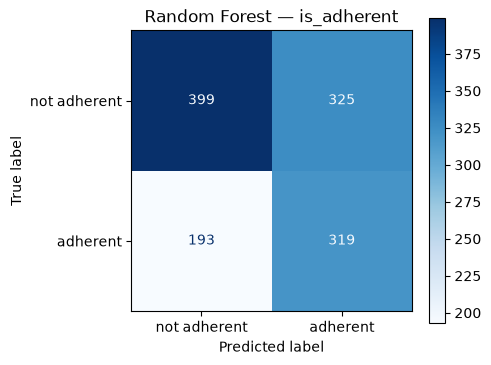

In [90]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.metrics import f1_score
import time

param_list = list(ParameterGrid(PARAM_GRID))
n_combos = len(param_list)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting grid search: {n_combos} param combos x {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits\n")

best_score = -np.inf
best_params = None
results = []
t0 = time.perf_counter()

for i, params in enumerate(param_list, start=1):
    fold_scores = []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = rf.predict(X_train.iloc[val_idx])
        fold_scores.append(f1_score(y_train.iloc[val_idx], pred))

    mean_score = float(np.mean(fold_scores))
    results.append({**params, "mean_f1": mean_score})

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

    elapsed = time.perf_counter() - t0
    avg_per_combo = elapsed / i
    remaining = avg_per_combo * (n_combos - i)
    print(
        f"[{i}/{n_combos}] mean_f1={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_f1={best_score:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params:", best_params)
print(f"Best CV f1: {best_score:.4f}")

# Refit best model on full training set, evaluate on holdout test
best_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not adherent", "adherent"]).plot(ax=ax, cmap="Blues")
ax.set_title("Random Forest — is_adherent")
plt.tight_layout()
plt.show()


Starting grid search (AUC): 432 param combos x 5 folds = 2160 fits

[1/432] mean_auc=0.6200 | elapsed=0.1m | ETA=27.7m | best_auc=0.6200
[2/432] mean_auc=0.6216 | elapsed=0.2m | ETA=37.2m | best_auc=0.6216
[3/432] mean_auc=0.6209 | elapsed=0.3m | ETA=46.9m | best_auc=0.6216
[4/432] mean_auc=0.6240 | elapsed=0.4m | ETA=41.7m | best_auc=0.6240
[5/432] mean_auc=0.6283 | elapsed=0.5m | ETA=42.0m | best_auc=0.6283
[6/432] mean_auc=0.6286 | elapsed=0.6m | ETA=45.3m | best_auc=0.6286
[7/432] mean_auc=0.6321 | elapsed=0.7m | ETA=42.3m | best_auc=0.6321
[8/432] mean_auc=0.6323 | elapsed=0.8m | ETA=42.2m | best_auc=0.6323
[9/432] mean_auc=0.6333 | elapsed=0.9m | ETA=44.4m | best_auc=0.6333
[10/432] mean_auc=0.6424 | elapsed=1.0m | ETA=42.1m | best_auc=0.6424
[11/432] mean_auc=0.6429 | elapsed=1.1m | ETA=41.8m | best_auc=0.6429
[12/432] mean_auc=0.6444 | elapsed=1.2m | ETA=43.1m | best_auc=0.6444
[13/432] mean_auc=0.6427 | elapsed=1.3m | ETA=41.4m | best_auc=0.6444
[14/432] mean_auc=0.6433 | elap

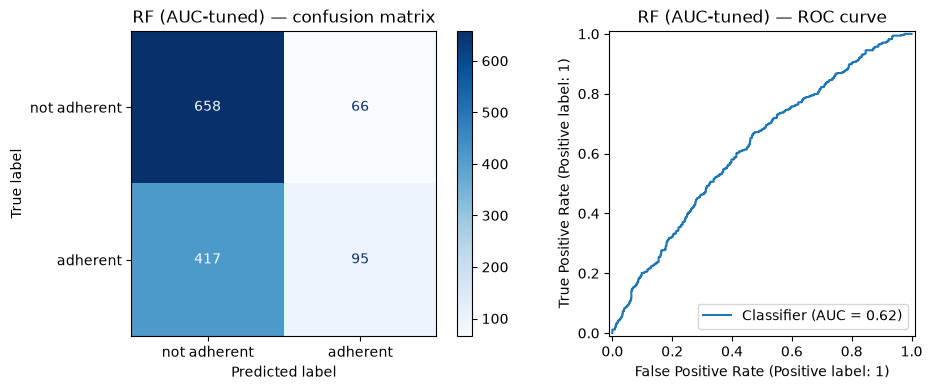

In [91]:
# Same grid search, tuned on ROC-AUC (with progress + ETA)
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import time

param_list = list(ParameterGrid(PARAM_GRID))
n_combos = len(param_list)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting grid search (AUC): {n_combos} param combos x {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits\n")

best_score_auc = -np.inf
best_params_auc = None
results_auc = []
t0 = time.perf_counter()

for i, params in enumerate(param_list, start=1):
    fold_scores = []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        proba = rf.predict_proba(X_train.iloc[val_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_train.iloc[val_idx], proba))

    mean_score = float(np.mean(fold_scores))
    results_auc.append({**params, "mean_auc": mean_score})

    if mean_score > best_score_auc:
        best_score_auc = mean_score
        best_params_auc = params

    elapsed = time.perf_counter() - t0
    avg_per_combo = elapsed / i
    remaining = avg_per_combo * (n_combos - i)
    print(
        f"[{i}/{n_combos}] mean_auc={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_auc={best_score_auc:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params (AUC):", best_params_auc)
print(f"Best CV AUC: {best_score_auc:.4f}")

# Refit best AUC model on full training set, evaluate on holdout test
best_rf_auc = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params_auc)
best_rf_auc.fit(X_train, y_train)
y_pred_auc = best_rf_auc.predict(X_test)
y_proba_auc = best_rf_auc.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_proba_auc):.4f}")
print("\nClassification report (test set, AUC-tuned model):")
print(classification_report(y_test, y_pred_auc, digits=3))

cm_auc = confusion_matrix(y_test, y_pred_auc)
print("Confusion matrix (test set):")
print(cm_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_auc, display_labels=["not adherent", "adherent"]).plot(
    ax=axes[0], cmap="Blues"
)
axes[0].set_title("RF (AUC-tuned) — confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba_auc, ax=axes[1])
axes[1].set_title("RF (AUC-tuned) — ROC curve")
plt.tight_layout()
plt.show()


/home/mehak/Documents/Personal/Friana/Medical-Adherence/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gini importance — top 20 (AUC-tuned RF)


,gini_importance
AGE23X,0.058389
ICD_E78,0.047191
ICD_I10,0.040239
FAMINC23,0.029946
PATIENT_COST_SHARE,0.029699
RX_ATORVASTATIN,0.028429
RX_LISINOPRIL,0.023951
RX_LEVOTHYROXIN,0.018397
RX_METOPROL SUC,0.015183
ICD_E03,0.015014


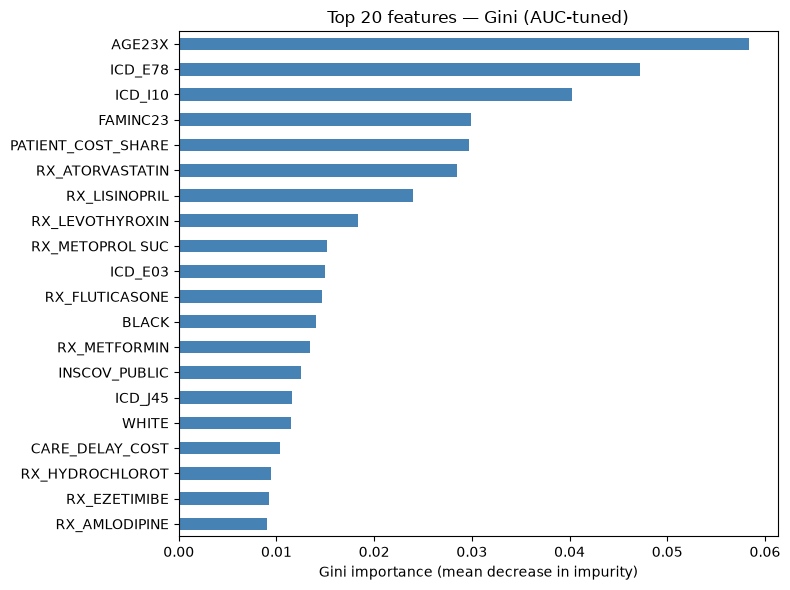

In [93]:
# Feature importance: Gini (RF impurity decrease) + SHAP
# Uses AUC-tuned model if available, else F1-tuned model.

import shap

model_for_imp = best_rf_auc if "best_rf_auc" in dir() else best_rf
model_label = "AUC-tuned" if "best_rf_auc" in dir() and model_for_imp is best_rf_auc else "F1-tuned"

TOP_N = 20  # edit: how many features to show

gini_imp = (
    pd.Series(model_for_imp.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(f"Gini importance — top {TOP_N} ({model_label} RF)")
display(gini_imp.head(TOP_N).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N} features — Gini ({model_label})")
plt.tight_layout()
plt.show()


SHAP mean |value| — top 20 (AUC-tuned RF, n=500)


,mean_abs_shap
ICD_I10,0.014265
ICD_E78,0.014214
AGE23X,0.010925
RX_ATORVASTATIN,0.008455
RX_LISINOPRIL,0.007480
INSCOV_PUBLIC,0.006459
RX_LEVOTHYROXIN,0.005411
BLACK,0.004768
WHITE,0.004723
RX_METFORMIN,0.004480


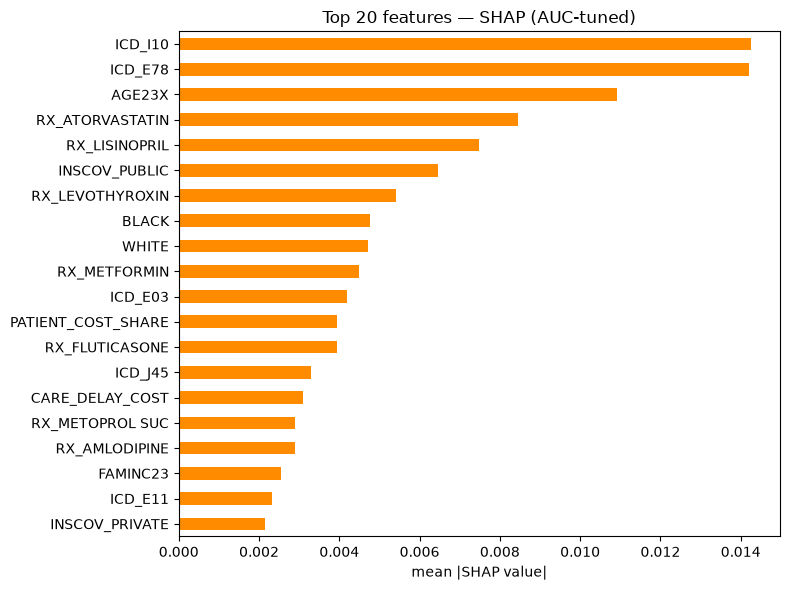

SHAP beeswarm (class = adherent):


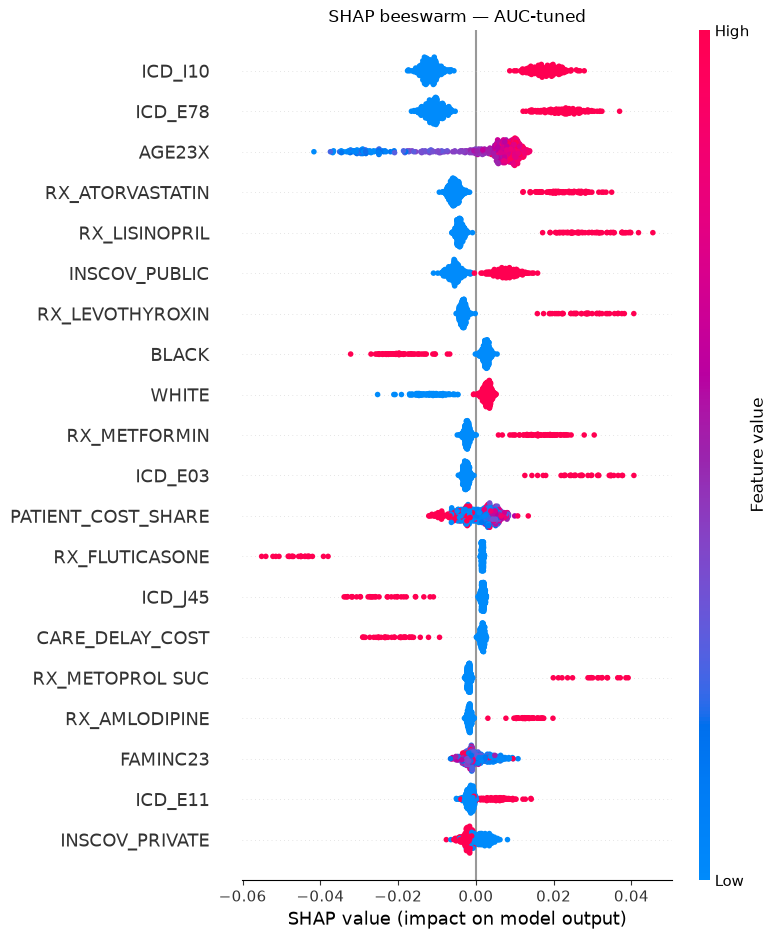

In [94]:
# SHAP values (TreeExplainer) — mean |SHAP| ranking + beeswarm
# Uses a sample of the training set for speed; raise SHAP_SAMPLE if you want more precision.

SHAP_SAMPLE = 500  # edit: number of rows for SHAP

X_shap = X_train.sample(n=min(SHAP_SAMPLE, len(X_train)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(model_for_imp)
shap_values = explainer.shap_values(X_shap)

# Binary RF: shap_values is often [class0, class1] or a 3D array depending on shap version
if isinstance(shap_values, list):
    shap_pos = shap_values[1]  # class 1 = adherent
elif getattr(shap_values, "ndim", 0) == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

mean_abs_shap = (
    pd.Series(np.abs(shap_pos).mean(axis=0), index=X_shap.columns)
    .sort_values(ascending=False)
)

print(f"SHAP mean |value| — top {TOP_N} ({model_label} RF, n={len(X_shap)})")
display(mean_abs_shap.head(TOP_N).to_frame("mean_abs_shap"))

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top {TOP_N} features — SHAP ({model_label})")
plt.tight_layout()
plt.show()

print("SHAP beeswarm (class = adherent):")
shap.summary_plot(shap_pos, X_shap, max_display=TOP_N, show=False)
plt.title(f"SHAP beeswarm — {model_label}")
plt.tight_layout()
plt.show()


Gini importance — top 20 (F1-tuned RF)
Best F1 params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


,gini_importance
AGE23X,0.079411
ICD_I10,0.062671
ICD_E78,0.054224
PATIENT_COST_SHARE,0.030286
RX_ATORVASTATIN,0.029950
FAMINC23,0.028923
RX_FLUTICASONE,0.023141
RX_METFORMIN,0.022527
ICD_E03,0.020335
RX_LEVOTHYROXIN,0.019896


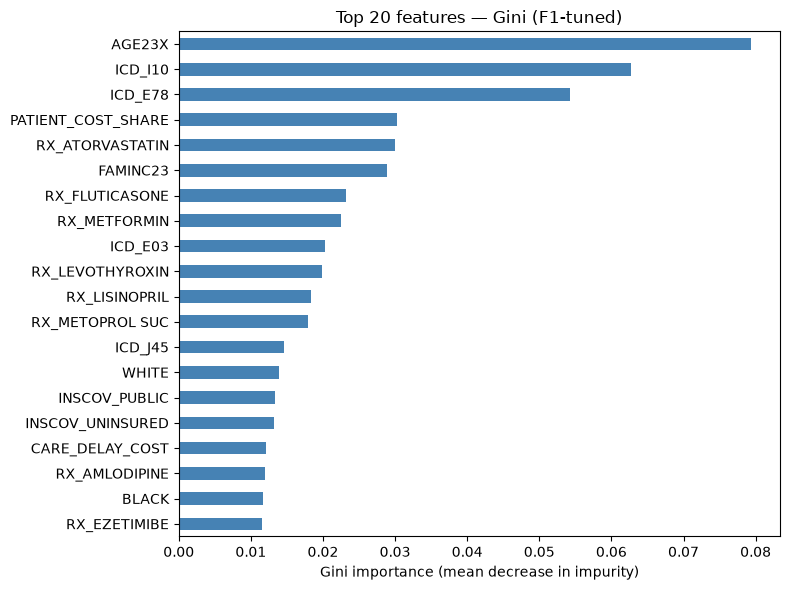

In [95]:
# F1-tuned RF — Gini feature importance
TOP_N_F1 = 20  # edit

gini_imp_f1 = (
    pd.Series(best_rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(f"Gini importance — top {TOP_N_F1} (F1-tuned RF)")
print("Best F1 params:", best_params)
display(gini_imp_f1.head(TOP_N_F1).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp_f1.head(TOP_N_F1).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N_F1} features — Gini (F1-tuned)")
plt.tight_layout()
plt.show()


SHAP mean |value| — top 20 (F1-tuned RF, n=500)


,mean_abs_shap
ICD_I10,0.016636
AGE23X,0.012625
ICD_E78,0.012492
INSCOV_PUBLIC,0.006844
RX_ATORVASTATIN,0.006700
RX_METFORMIN,0.006046
RX_LEVOTHYROXIN,0.004687
ICD_E03,0.004395
RX_LISINOPRIL,0.004382
WHITE,0.004199


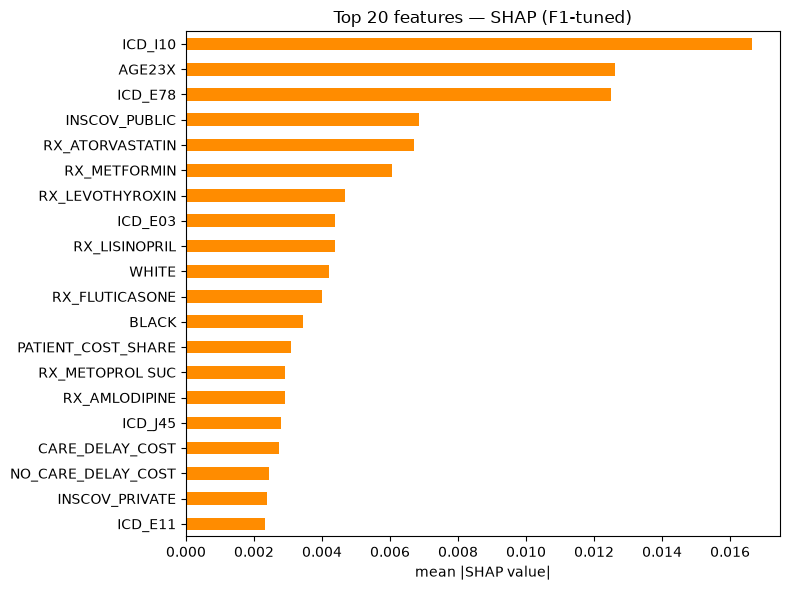

SHAP beeswarm (class = adherent, F1-tuned):


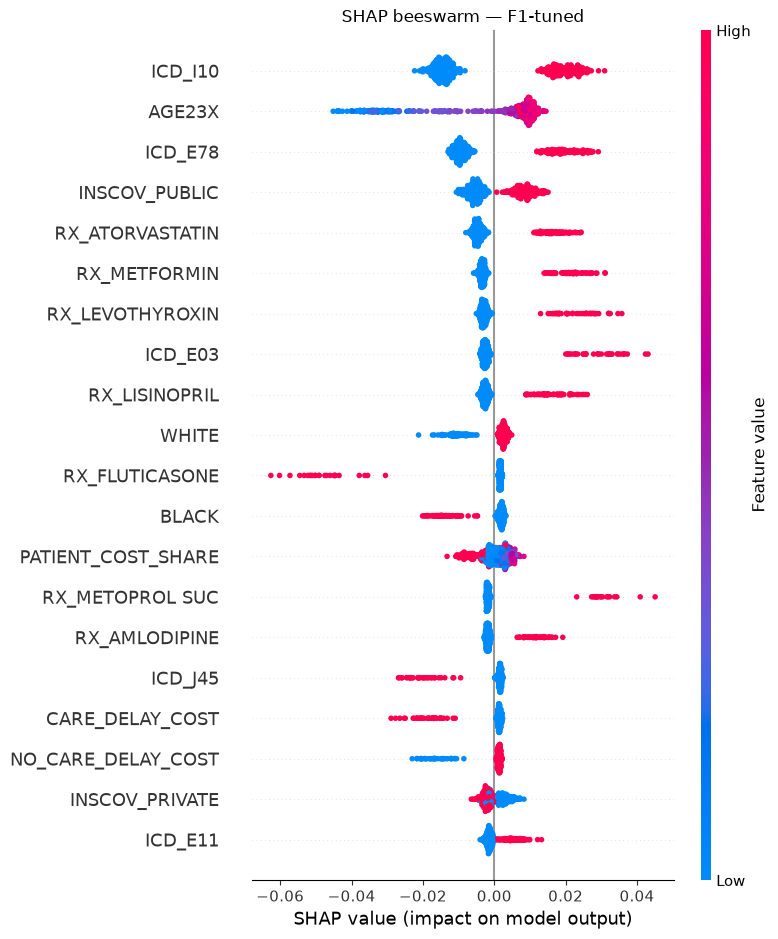

In [96]:
# F1-tuned RF — SHAP feature importance
import shap

SHAP_SAMPLE_F1 = 500  # edit

X_shap_f1 = X_train.sample(n=min(SHAP_SAMPLE_F1, len(X_train)), random_state=RANDOM_STATE)

explainer_f1 = shap.TreeExplainer(best_rf)
shap_values_f1 = explainer_f1.shap_values(X_shap_f1)

if isinstance(shap_values_f1, list):
    shap_pos_f1 = shap_values_f1[1]
elif getattr(shap_values_f1, "ndim", 0) == 3:
    shap_pos_f1 = shap_values_f1[:, :, 1]
else:
    shap_pos_f1 = shap_values_f1

mean_abs_shap_f1 = (
    pd.Series(np.abs(shap_pos_f1).mean(axis=0), index=X_shap_f1.columns)
    .sort_values(ascending=False)
)

print(f"SHAP mean |value| — top {TOP_N_F1} (F1-tuned RF, n={len(X_shap_f1)})")
display(mean_abs_shap_f1.head(TOP_N_F1).to_frame("mean_abs_shap"))

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap_f1.head(TOP_N_F1).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top {TOP_N_F1} features — SHAP (F1-tuned)")
plt.tight_layout()
plt.show()

print("SHAP beeswarm (class = adherent, F1-tuned):")
shap.summary_plot(shap_pos_f1, X_shap_f1, max_display=TOP_N_F1, show=False)
plt.title("SHAP beeswarm — F1-tuned")
plt.tight_layout()
plt.show()


In [97]:
# RF with n_drugs + n_conditions included as features
# (still drops meps_adherence_ratio to avoid leakage)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, ParameterGrid, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
import time

# Ensure count columns exist on patient-level model_df
rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]
model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

PARAM_GRID_NC = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42

drop_cols_nc = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage — still dropped
    # n_drugs / n_conditions KEPT as features
]

X_nc = model_df.drop(columns=[c for c in drop_cols_nc if c in model_df.columns])
y_nc = model_df["is_adherent"]

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_nc, y_nc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_nc
)

print("Features include n_drugs / n_conditions:", 
      "n_drugs" in X_nc.columns and "n_conditions" in X_nc.columns)
print(f"X_nc shape: {X_nc.shape} | train: {X_train_nc.shape[0]} | test: {X_test_nc.shape[0]}")
print(f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID_NC.values()])} x {CV_FOLDS} folds")


Features include n_drugs / n_conditions: True
X_nc shape: (6180, 573) | train: 4944 | test: 1236
GridSearch combos: 432 x 5 folds


In [ ]:
# Grid search (F1) for RF with n_drugs + n_conditions — progress + ETA
param_list_nc = list(ParameterGrid(PARAM_GRID_NC))
n_combos_nc = len(param_list_nc)
cv_nc = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(
    f"Starting grid search (F1, with n_drugs/n_conditions): "
    f"{n_combos_nc} combos x {CV_FOLDS} folds = {n_combos_nc * CV_FOLDS} fits\n"
)

best_score_nc = -np.inf
best_params_nc = None
results_nc = []
t0 = time.perf_counter()

for i, params in enumerate(param_list_nc, start=1):
    fold_scores = []
    for train_idx, val_idx in cv_nc.split(X_train_nc, y_train_nc):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train_nc.iloc[train_idx], y_train_nc.iloc[train_idx])
        pred = rf.predict(X_train_nc.iloc[val_idx])
        fold_scores.append(f1_score(y_train_nc.iloc[val_idx], pred))

    mean_score = float(np.mean(fold_scores))
    results_nc.append({**params, "mean_f1": mean_score})

    if mean_score > best_score_nc:
        best_score_nc = mean_score
        best_params_nc = params

    elapsed = time.perf_counter() - t0
    remaining = (elapsed / i) * (n_combos_nc - i)
    print(
        f"[{i}/{n_combos_nc}] mean_f1={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_f1={best_score_nc:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params (with n_drugs/n_conditions):", best_params_nc)
print(f"Best CV f1: {best_score_nc:.4f}")

best_rf_nc = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params_nc)
best_rf_nc.fit(X_train_nc, y_train_nc)
y_pred_nc = best_rf_nc.predict(X_test_nc)

print("\nClassification report (test set, with n_drugs/n_conditions):")
print(classification_report(y_test_nc, y_pred_nc, digits=3))

cm_nc = confusion_matrix(y_test_nc, y_pred_nc)
print("Confusion matrix (test set):")
print(cm_nc)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm_nc, display_labels=["not adherent", "adherent"]
).plot(ax=ax, cmap="Blues")
ax.set_title("RF (F1) — with n_drugs & n_conditions")
plt.tight_layout()
plt.show()


Starting grid search (F1, with n_drugs/n_conditions): 432 combos x 5 folds = 2160 fits

[1/432] mean_f1=0.4464 | elapsed=0.1m | ETA=24.6m | best_f1=0.4464
[2/432] mean_f1=0.4467 | elapsed=0.2m | ETA=33.0m | best_f1=0.4467
[3/432] mean_f1=0.4434 | elapsed=0.3m | ETA=41.7m | best_f1=0.4467
[4/432] mean_f1=0.4471 | elapsed=0.3m | ETA=37.3m | best_f1=0.4471
[5/432] mean_f1=0.4456 | elapsed=0.4m | ETA=38.0m | best_f1=0.4471
[6/432] mean_f1=0.4408 | elapsed=0.6m | ETA=41.2m | best_f1=0.4471
[7/432] mean_f1=0.4394 | elapsed=0.6m | ETA=38.6m | best_f1=0.4471
[8/432] mean_f1=0.4383 | elapsed=0.7m | ETA=38.6m | best_f1=0.4471
[9/432] mean_f1=0.4371 | elapsed=0.9m | ETA=40.8m | best_f1=0.4471
[10/432] mean_f1=0.4130 | elapsed=0.9m | ETA=38.8m | best_f1=0.4471
[11/432] mean_f1=0.4168 | elapsed=1.0m | ETA=38.8m | best_f1=0.4471
[12/432] mean_f1=0.4178 | elapsed=1.1m | ETA=39.9m | best_f1=0.4471
[13/432] mean_f1=0.4156 | elapsed=1.2m | ETA=38.4m | best_f1=0.4471
[14/432] mean_f1=0.4106 | elapsed=1.3

Starting grid search (AUC, with n_drugs/n_conditions): 432 combos x 5 folds = 2160 fits

[1/432] mean_auc=0.6072 | elapsed=0.0m | ETA=12.3m | best_auc=0.6072
[2/432] mean_auc=0.6083 | elapsed=0.1m | ETA=20.6m | best_auc=0.6083
[3/432] mean_auc=0.6106 | elapsed=0.2m | ETA=27.4m | best_auc=0.6106
[4/432] mean_auc=0.6185 | elapsed=0.2m | ETA=23.9m | best_auc=0.6185
[5/432] mean_auc=0.6219 | elapsed=0.3m | ETA=26.0m | best_auc=0.6219
[6/432] mean_auc=0.6232 | elapsed=0.4m | ETA=28.7m | best_auc=0.6232
[7/432] mean_auc=0.6273 | elapsed=0.4m | ETA=26.8m | best_auc=0.6273
[8/432] mean_auc=0.6282 | elapsed=0.5m | ETA=25.9m | best_auc=0.6282
[9/432] mean_auc=0.6282 | elapsed=0.6m | ETA=26.7m | best_auc=0.6282
[10/432] mean_auc=0.6343 | elapsed=0.6m | ETA=24.9m | best_auc=0.6343
[11/432] mean_auc=0.6342 | elapsed=0.6m | ETA=24.7m | best_auc=0.6343
[12/432] mean_auc=0.6354 | elapsed=0.7m | ETA=24.7m | best_auc=0.6354
[13/432] mean_auc=0.6317 | elapsed=0.7m | ETA=23.4m | best_auc=0.6354
[14/432] m

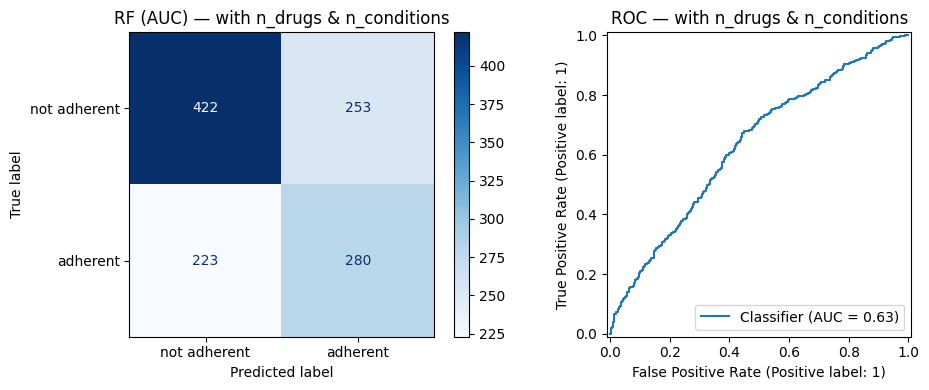

In [ ]:
# Grid search (AUC) for RF with n_drugs + n_conditions — progress + ETA
from sklearn.metrics import roc_auc_score, RocCurveDisplay

param_list_nc = list(ParameterGrid(PARAM_GRID_NC))
n_combos_nc = len(param_list_nc)
cv_nc = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(
    f"Starting grid search (AUC, with n_drugs/n_conditions): "
    f"{n_combos_nc} combos x {CV_FOLDS} folds = {n_combos_nc * CV_FOLDS} fits\n"
)

best_score_nc_auc = -np.inf
best_params_nc_auc = None
results_nc_auc = []
t0 = time.perf_counter()

for i, params in enumerate(param_list_nc, start=1):
    fold_scores = []
    for train_idx, val_idx in cv_nc.split(X_train_nc, y_train_nc):
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        rf.fit(X_train_nc.iloc[train_idx], y_train_nc.iloc[train_idx])
        proba = rf.predict_proba(X_train_nc.iloc[val_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_train_nc.iloc[val_idx], proba))

    mean_score = float(np.mean(fold_scores))
    results_nc_auc.append({**params, "mean_auc": mean_score})

    if mean_score > best_score_nc_auc:
        best_score_nc_auc = mean_score
        best_params_nc_auc = params

    elapsed = time.perf_counter() - t0
    remaining = (elapsed / i) * (n_combos_nc - i)
    print(
        f"[{i}/{n_combos_nc}] mean_auc={mean_score:.4f} | "
        f"elapsed={elapsed/60:.1f}m | ETA={remaining/60:.1f}m | "
        f"best_auc={best_score_nc_auc:.4f}"
    )

print(f"\nDone in {(time.perf_counter() - t0)/60:.1f} minutes")
print("Best params (AUC, with n_drugs/n_conditions):", best_params_nc_auc)
print(f"Best CV AUC: {best_score_nc_auc:.4f}")

best_rf_nc_auc = RandomForestClassifier(
    random_state=RANDOM_STATE, n_jobs=-1, **best_params_nc_auc
)
best_rf_nc_auc.fit(X_train_nc, y_train_nc)
y_pred_nc_auc = best_rf_nc_auc.predict(X_test_nc)
y_proba_nc_auc = best_rf_nc_auc.predict_proba(X_test_nc)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test_nc, y_proba_nc_auc):.4f}")
print("\nClassification report (test set, AUC-tuned with n_drugs/n_conditions):")
print(classification_report(y_test_nc, y_pred_nc_auc, digits=3))

cm_nc_auc = confusion_matrix(y_test_nc, y_pred_nc_auc)
print("Confusion matrix (test set):")
print(cm_nc_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm_nc_auc, display_labels=["not adherent", "adherent"]
).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("RF (AUC) — with n_drugs & n_conditions")
RocCurveDisplay.from_predictions(y_test_nc, y_proba_nc_auc, ax=axes[1])
axes[1].set_title("ROC — with n_drugs & n_conditions")
plt.tight_layout()
plt.show()
